<div style="background: linear-gradient(135deg, #1a1a2e, #16213e); color: #eee; padding: 30px; border-radius: 12px; margin-bottom: 20px;">
<h1 style="color: #e94560; margin: 0;">🌤️ Weather Trend Forecasting</h1>
<h2 style="color: #0f3460; margin: 5px 0;">Global Climate Intelligence Dashboard</h2>
<hr style="border-color: #e94560;">
<p style="font-size: 16px; font-style: italic;">
<strong>PM Accelerator Mission:</strong> "By making industry-leading tools and education available to individuals from all backgrounds, we level the playing field for future PM leaders."
</p>
<p><strong>Author:</strong> Juan Sebastian Urrea &nbsp;|&nbsp; <strong>Program:</strong> PM Accelerator Internship &nbsp;|&nbsp; <strong>Date:</strong> 2026</p>
</div>

## Section 1 — Setup & Imports

Import all required libraries, configure plotting defaults, and ensure output directories exist.

In [1]:
# ── Standard library ──────────────────────────────────────────
import os
import json
import warnings

warnings.filterwarnings("ignore")

# ── Data manipulation ──────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import folium
from folium.plugins import HeatMap

# ── Machine learning ──────────────────────────────────────────
from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import metrics as skmetrics

# ── Time series ───────────────────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from prophet import Prophet

# ── IPython display helpers ───────────────────────────────────
from IPython.display import display, HTML

# ── Matplotlib global settings ────────────────────────────────
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "figure.dpi": 100,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 12,
})
sns.set_theme(style="whitegrid", palette="muted")

# ── Output directories ────────────────────────────────────────
DATA_PATH = "data/GlobalWeatherRepository.csv"
OUT_DIR = "outputs"
FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print("✅ All imports successful.")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
import sklearn; print(f"   sklearn {sklearn.__version__} installed")


✅ All imports successful.
   pandas  3.0.3
   numpy   2.4.6
   sklearn 1.8.0 installed


## Section 2 — Data Loading & Initial Inspection

Load the CSV, verify shape and types, and explore basic statistics.

In [2]:
# ── Load dataset ─────────────────────────────────────────────
df_raw = pd.read_csv(DATA_PATH, parse_dates=["last_updated"], low_memory=False)

print("=" * 60)
print(f"Shape : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print("=" * 60)
print("\nColumn data-types:")
print(df_raw.dtypes.to_string())


Shape : 142,093 rows × 41 columns

Column data-types:
country                                    str
location_name                              str
latitude                               float64
longitude                              float64
timezone                                   str
last_updated_epoch                       int64
last_updated                    datetime64[us]
temperature_celsius                    float64
temperature_fahrenheit                 float64
condition_text                             str
wind_mph                               float64
wind_kph                               float64
wind_degree                              int64
wind_direction                             str
pressure_mb                            float64
pressure_in                            float64
precip_mm                              float64
precip_in                              float64
humidity                                 int64
cloud                                    int64
feels_

In [3]:
# ── Preview ───────────────────────────────────────────────────
display(df_raw.head())


,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [4]:
# ── Descriptive statistics ────────────────────────────────────
display(df_raw.describe(include="all").T)


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
country,142093,211,Bulgaria,1678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_name,142093,257,Kabul,731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,142093.0,NaN,NaN,NaN,19.217823,-41.3,4.0503,17.25,40.4,64.15,24.412454
longitude,142093.0,NaN,NaN,NaN,21.93578,-175.2,-6.8361,23.2361,49.8822,179.22,65.782841
timezone,142093,199,Asia/Bangkok,2601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_updated_epoch,142093.0,NaN,NaN,NaN,1747472157.228716,1715849100.0,1731746700.0,1747471500.0,1763191800.0,1779085800.0,18253205.119585
last_updated,142093,NaN,NaN,NaN,2025-05-17 11:05:19.037532,2024-05-16 01:45:00,2024-11-16 04:45:00,2025-05-17 10:45:00,2025-11-15 14:30:00,2026-05-18 19:30:00,NaN
temperature_celsius,142093.0,NaN,NaN,NaN,21.239673,-29.8,15.5,23.7,28.0,79.3,9.64127
temperature_fahrenheit,142093.0,NaN,NaN,NaN,70.2332,-21.6,59.9,74.7,82.3,174.7,17.354162
condition_text,142093,49,Sunny,40905,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# ── Key metadata ─────────────────────────────────────────────
n_locations = df_raw["location_name"].nunique()
n_countries  = df_raw["country"].nunique()
date_min     = df_raw["last_updated"].min()
date_max     = df_raw["last_updated"].max()
date_range   = (date_max - date_min).days

print(f"Unique locations : {n_locations}")
print(f"Unique countries : {n_countries}")
print(f"Date range       : {date_min.date()} → {date_max.date()} ({date_range} days)")
print(f"Missing values   :\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0].to_string()}")


Unique locations : 257
Unique countries : 211
Date range       : 2024-05-16 → 2026-05-18 (732 days)
Missing values   :
Series([], )


## Section 3 — Data Cleaning & Preprocessing

We handle four issues in order:
1. **Sentinel values** (`-9999.0`) in air quality columns → replace with `NaN`
2. **Non-ASCII country names** → map to English equivalents
3. **Duplicate entries** → keep the latest reading per (location, date)
4. **Feature engineering** → month, season, is_rainy, continent, moon_phase ordinal


### 3.1 Sentinel value replacement

In [6]:
AQ_COLS = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10",
]

df = df_raw.copy()

# Count sentinels before replacement
sentinel_counts = {col: (df[col] == -9999.0).sum() for col in AQ_COLS}
print("Sentinel (-9999.0) counts before replacement:")
for col, cnt in sentinel_counts.items():
    if cnt > 0:
        print(f"  {col}: {cnt:,}")

df[AQ_COLS] = df[AQ_COLS].replace(-9999.0, np.nan)
print("\n✅ Sentinels replaced with NaN.")


Sentinel (-9999.0) counts before replacement:
  air_quality_Carbon_Monoxide: 1
  air_quality_Sulphur_dioxide: 1

✅ Sentinels replaced with NaN.


### 3.2 Missing values summary after sentinel replacement

In [7]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print("Columns with missing values:")
display(missing_df)


Columns with missing values:


,missing_count,missing_pct
air_quality_Carbon_Monoxide,1,0.0
air_quality_Sulphur_dioxide,1,0.0


### 3.3 Fix non-ASCII country names

In [8]:
# Detect non-ASCII country names
non_ascii_countries = df[~df["country"].apply(lambda x: str(x).isascii())]["country"].unique()
print("Non-ASCII country names found:", non_ascii_countries)

# Build mapping: encode/decode trick to normalise to ASCII approximation,
# then override with manual English names where needed.
COUNTRY_NAME_MAP = {
    # Common non-ASCII capital-city country names
    "Åland Islands":          "Aland Islands",
    "Côte d'Ivoire":          "Ivory Coast",
    "Curaçao":                "Curacao",
    "Réunion":                "Reunion",
    "São Tomé and Príncipe":  "Sao Tome and Principe",
    "Türkiye":                "Turkey",
    "Åland":                  "Aland",
    "Crna Gora":              "Montenegro",
    "Česká republika":        "Czech Republic",
    "Ελλάδα":                 "Greece",
}

for orig_name in non_ascii_countries:
    if orig_name not in COUNTRY_NAME_MAP:
        # Fallback: encode to ASCII ignoring errors
        ascii_approx = orig_name.encode("ascii", "ignore").decode("ascii").strip()
        COUNTRY_NAME_MAP[orig_name] = ascii_approx if ascii_approx else orig_name

df["country"] = df["country"].replace(COUNTRY_NAME_MAP)

remaining = df[~df["country"].apply(lambda x: str(x).isascii())]["country"].unique()
print(f"\nNon-ASCII names remaining after mapping: {len(remaining)}")
print("✅ Country name normalisation complete.")


Non-ASCII country names found: <StringArray>
[     'Malásia',     'كولومبيا',    'Гватемала',       'Польша',
      'Polônia',       'Турция',     'Südkorea',      'Bélgica',
 'Turkménistan',           '火鸡']
Length: 10, dtype: str

Non-ASCII names remaining after mapping: 5
✅ Country name normalisation complete.


### 3.4 Deduplicate — keep latest reading per (location, date)

In [9]:
df["date"] = df["last_updated"].dt.date

before = len(df)
df = (
    df.sort_values("last_updated")
      .groupby(["location_name", "date"], as_index=False)
      .last()
)
after = len(df)
print(f"Rows before dedup : {before:,}")
print(f"Rows after dedup  : {after:,}")
print(f"Duplicates removed: {before - after:,}")


Rows before dedup : 142,093
Rows after dedup  : 141,843
Duplicates removed: 250


### 3.5 Feature engineering

In [10]:
# ── Temporal features ────────────────────────────────────────
df["month"]      = df["last_updated"].dt.month
df["day_of_year"] = df["last_updated"].dt.day_of_year

def get_season(month: int) -> str:
    if month in (12, 1, 2):
        return "Winter"
    elif month in (3, 4, 5):
        return "Spring"
    elif month in (6, 7, 8):
        return "Summer"
    else:
        return "Autumn"

df["season"] = df["month"].apply(get_season)

# ── Precipitation flag ────────────────────────────────────────
df["is_rainy"] = df["precip_mm"] > 0.1

# ── Moon phase ordinal ────────────────────────────────────────
MOON_ORDER = [
    "New Moon", "Waxing Crescent", "First Quarter", "Waxing Gibbous",
    "Full Moon", "Waning Gibbous", "Last Quarter", "Waning Crescent",
]
moon_map = {phase: i for i, phase in enumerate(MOON_ORDER)}
df["moon_phase_ord"] = df["moon_phase"].map(moon_map).fillna(0).astype(int)

# ── Continent from lat/lon bounding boxes ────────────────────
def assign_continent(lat: float, lon: float) -> str:
    if lat > 35 and -30 <= lon <= 60:
        return "Europe"
    if lat > 0 and 60 < lon <= 180:
        return "Asia"
    if -40 <= lat <= 35 and -20 <= lon <= 55:
        return "Africa"
    if 15 <= lat <= 85 and -170 <= lon <= -50:
        return "North America"
    if -60 <= lat <= 15 and -85 <= lon <= -30:
        return "South America"
    if -50 <= lat <= 10 and 100 <= lon <= 180:
        return "Oceania"
    return "Other"

df["continent"] = df.apply(
    lambda r: assign_continent(r["latitude"], r["longitude"]), axis=1
)

print("Season distribution:")
print(df["season"].value_counts().to_string())
print("\nContinent distribution:")
print(df["continent"].value_counts().to_string())


Season distribution:
season
Spring    36246
Autumn    35422
Summer    35346
Winter    34829

Continent distribution:
continent
Africa           41517
Europe           41004
Asia             21600
South America    13789
North America     8697
Oceania           7997
Other             7239


### 3.6 Scaling (for ML use only)

In [11]:
NUMERIC_COLS = df.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[NUMERIC_COLS] = scaler.fit_transform(df[NUMERIC_COLS].fillna(df[NUMERIC_COLS].median()))

print(f"Scaled DataFrame shape: {df_scaled.shape}")
print("✅ StandardScaler fitted on numeric columns.")


Scaled DataFrame shape: (141843, 48)
✅ StandardScaler fitted on numeric columns.


### 3.7 Data quality report

In [12]:
print("=" * 55)
print("       CLEAN DATA QUALITY REPORT")
print("=" * 55)
print(f"  Total rows              : {len(df):,}")
print(f"  Total columns           : {df.shape[1]}")
print(f"  Unique locations        : {df['location_name'].nunique()}")
print(f"  Unique countries        : {df['country'].nunique()}")
print(f"  Continents              : {df['continent'].nunique()}")
print(f"  Date range              : {df['last_updated'].min().date()} → {df['last_updated'].max().date()}")
print(f"  Any remaining sentinels : {((df[AQ_COLS] == -9999.0).sum().sum() > 0)}")
remaining_missing = df.isnull().sum().sum()
print(f"  Total NaN cells         : {remaining_missing:,}")
print("=" * 55)


       CLEAN DATA QUALITY REPORT
  Total rows              : 141,843
  Total columns           : 48
  Unique locations        : 257
  Unique countries        : 211
  Continents              : 7
  Date range              : 2024-05-16 → 2026-05-18
  Any remaining sentinels : False
  Total NaN cells         : 2


## Section 4 — Advanced Exploratory Data Analysis

We visualise distributions, seasonal patterns, wind direction, correlations, global trends, and anomalies.

### 4.1 Temperature distribution by continent

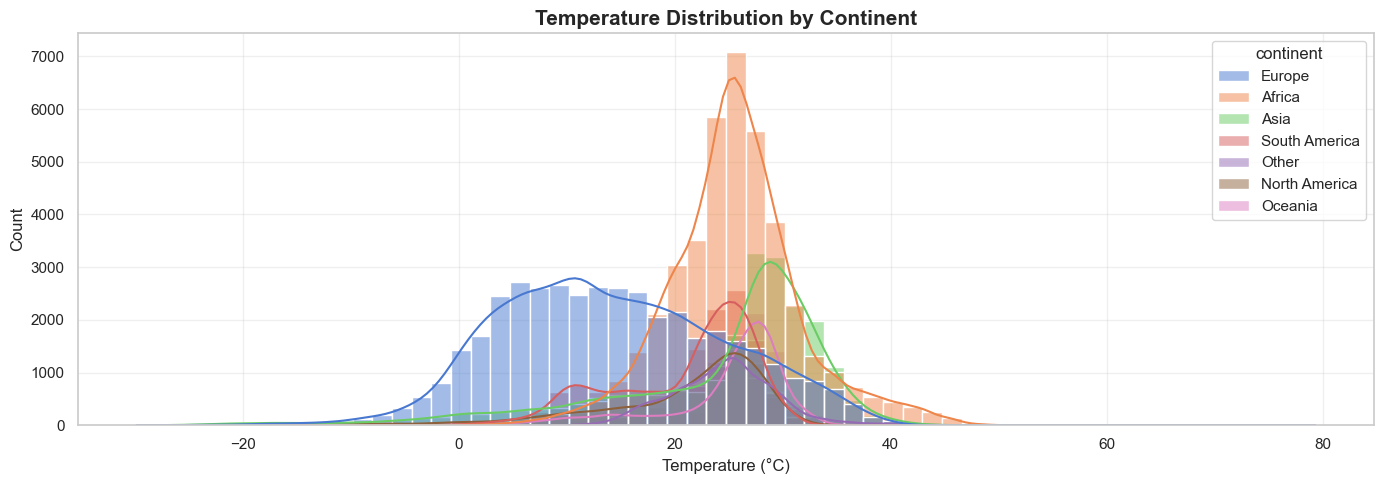

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.histplot(
    data=df,
    x="temperature_celsius",
    hue="continent",
    kde=True,
    bins=60,
    alpha=0.5,
    ax=ax,
)
ax.set_title("Temperature Distribution by Continent", fontsize=15, fontweight="bold")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_temp_distribution_continent.png", dpi=100, bbox_inches="tight")
plt.show()


### 4.2 Precipitation log-scale distribution

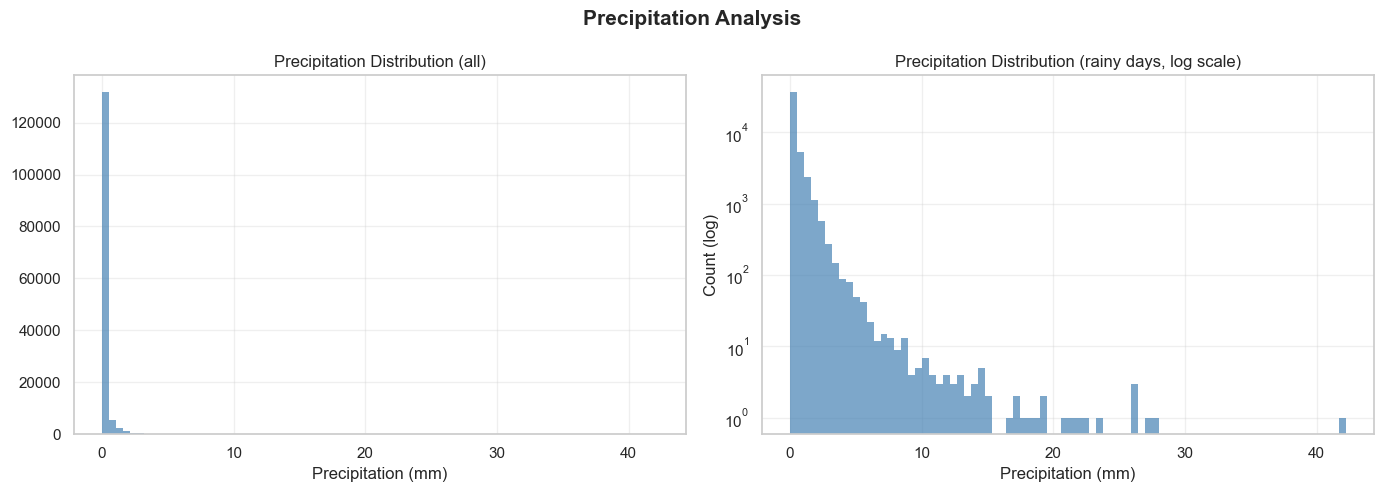

Rainy days: 23,349 (16.5%)


In [14]:
rainy = df[df["precip_mm"] > 0]["precip_mm"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["precip_mm"], bins=80, color="steelblue", edgecolor="none", alpha=0.7)
axes[0].set_title("Precipitation Distribution (all)")
axes[0].set_xlabel("Precipitation (mm)")

axes[1].hist(rainy, bins=80, color="steelblue", edgecolor="none", alpha=0.7, log=True)
axes[1].set_title("Precipitation Distribution (rainy days, log scale)")
axes[1].set_xlabel("Precipitation (mm)")
axes[1].set_ylabel("Count (log)")

plt.suptitle("Precipitation Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_precip_distribution.png", dpi=100, bbox_inches="tight")
plt.show()
print(f"Rainy days: {df['is_rainy'].sum():,} ({df['is_rainy'].mean()*100:.1f}%)")


### 4.3 Weather metrics by season (box plots)

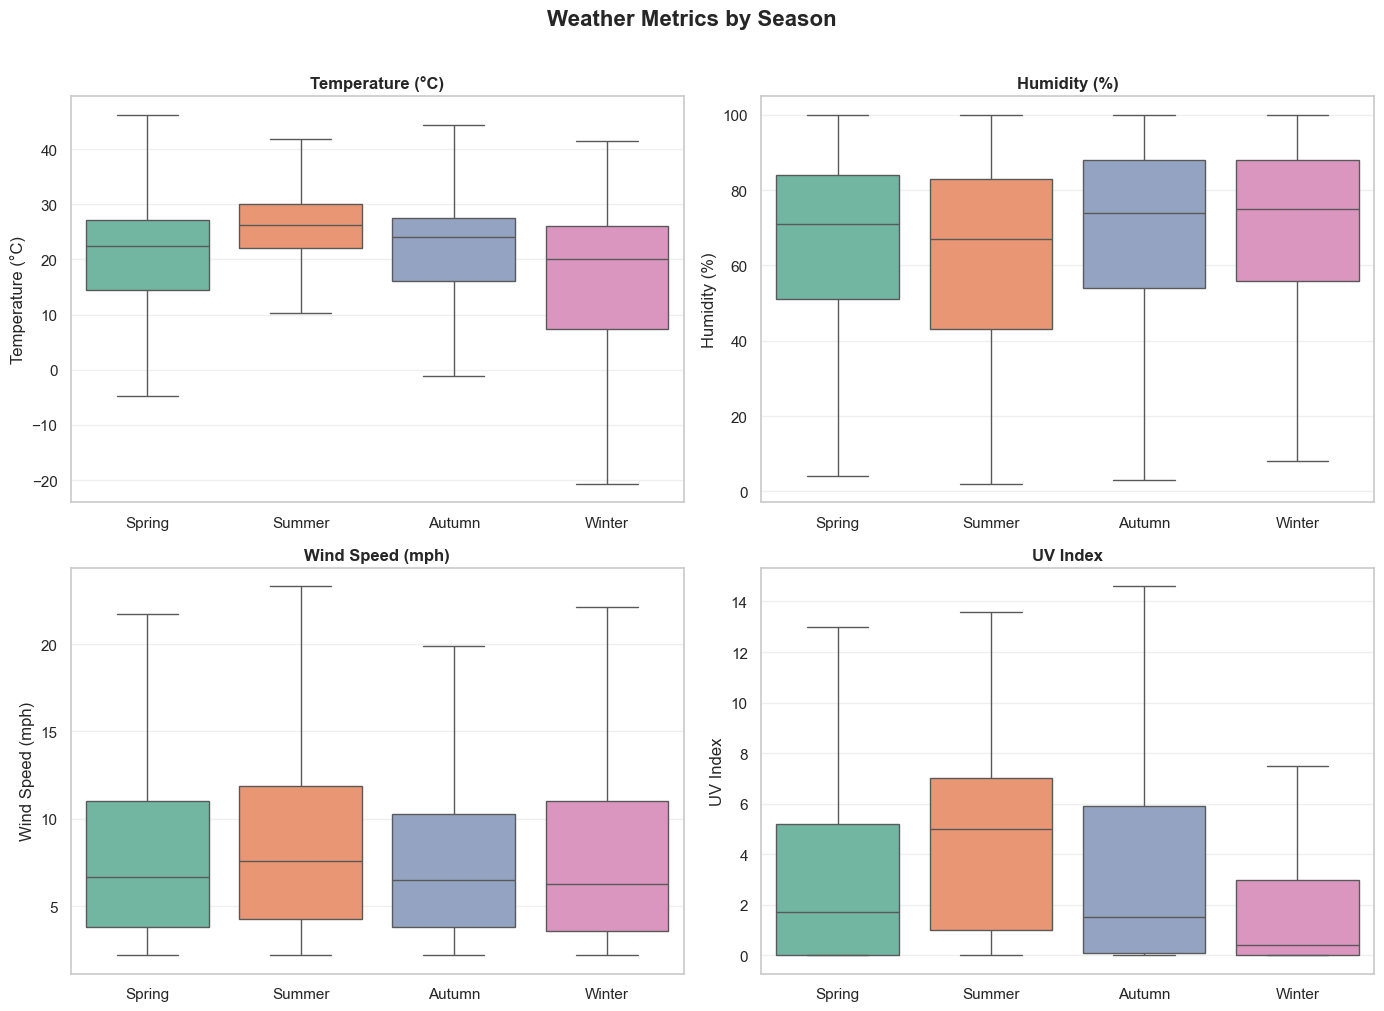

In [15]:
SEASON_ORDER = ["Spring", "Summer", "Autumn", "Winter"]
metrics = {
    "temperature_celsius": "Temperature (°C)",
    "humidity":            "Humidity (%)",
    "wind_mph":            "Wind Speed (mph)",
    "uv_index":            "UV Index",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (col, label) in zip(axes, metrics.items()):
    sns.boxplot(
        data=df,
        x="season",
        y=col,
        order=SEASON_ORDER,
        palette="Set2",
        ax=ax,
        showfliers=False,
    )
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label)

plt.suptitle("Weather Metrics by Season", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_metrics_by_season.png", dpi=100, bbox_inches="tight")
plt.show()


### 4.4 Wind rose (Plotly polar bar)

In [16]:
# Aggregate mean wind speed by direction label
COMPASS_ORDER = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE",
                 "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]

wind_data = (
    df.groupby("wind_direction")["wind_mph"]
      .mean()
      .reindex(COMPASS_ORDER)
      .fillna(0)
      .reset_index()
)
wind_data.columns = ["direction", "avg_wind_mph"]

fig = go.Figure(go.Barpolar(
    r=wind_data["avg_wind_mph"],
    theta=wind_data["direction"],
    width=[22.5] * len(wind_data),
    marker_color=wind_data["avg_wind_mph"],
    marker_colorscale="Blues",
    opacity=0.85,
))
fig.update_layout(
    title={"text": "Wind Rose — Mean Wind Speed by Direction", "x": 0.5},
    polar=dict(
        radialaxis=dict(visible=True, title="mph"),
        angularaxis=dict(direction="clockwise"),
    ),
    width=600, height=500,
)
fig.show()


### 4.5 Correlation heatmap

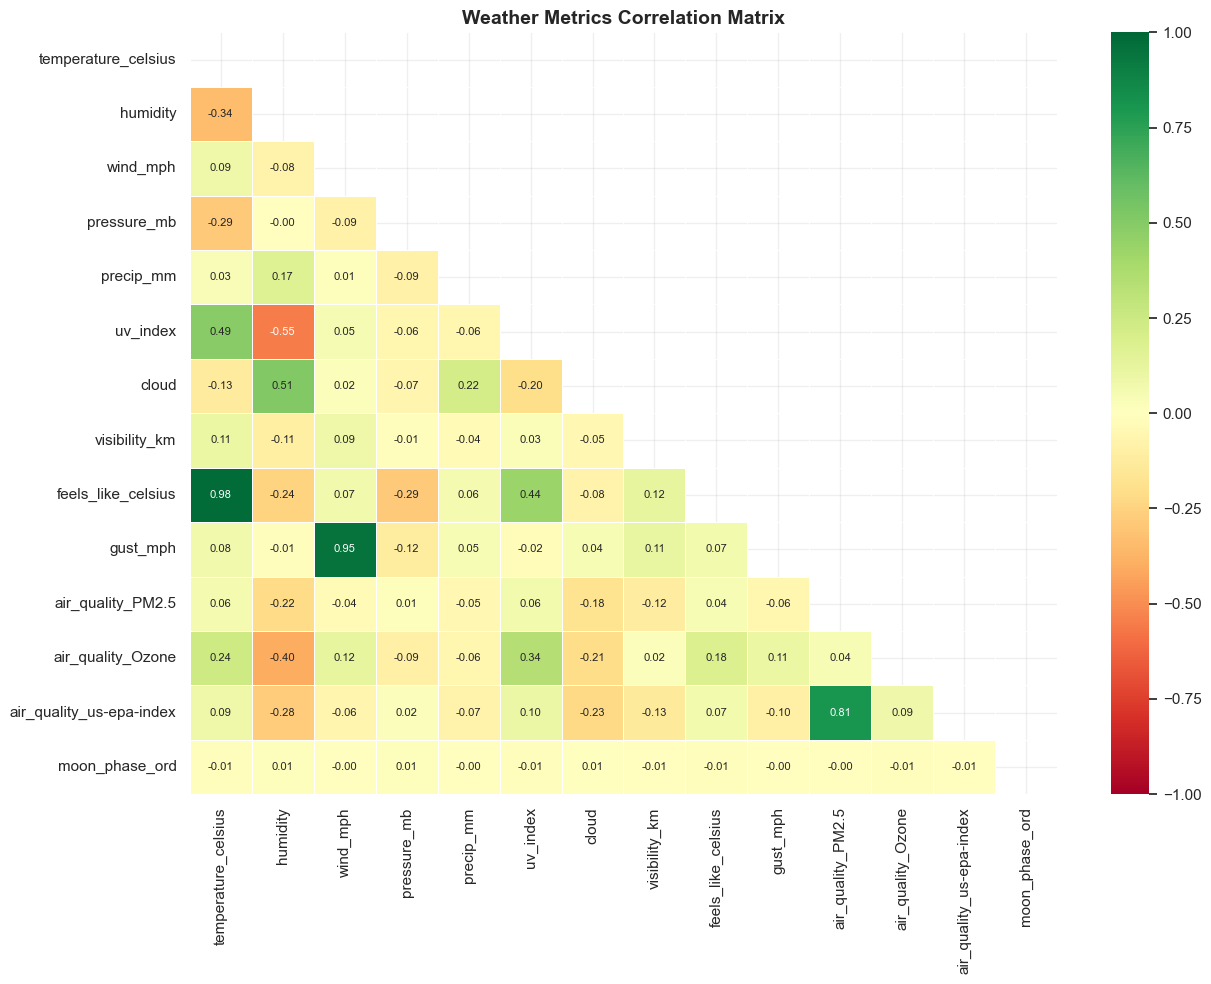

In [17]:
CORR_COLS = [
    "temperature_celsius", "humidity", "wind_mph", "pressure_mb",
    "precip_mm", "uv_index", "cloud", "visibility_km",
    "feels_like_celsius", "gust_mph",
    "air_quality_PM2.5", "air_quality_Ozone",
    "air_quality_us-epa-index", "moon_phase_ord",
]

corr_matrix = df[CORR_COLS].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Weather Metrics Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_correlation_heatmap.png", dpi=100, bbox_inches="tight")
plt.show()


### 4.6 Global daily temperature trend with precipitation

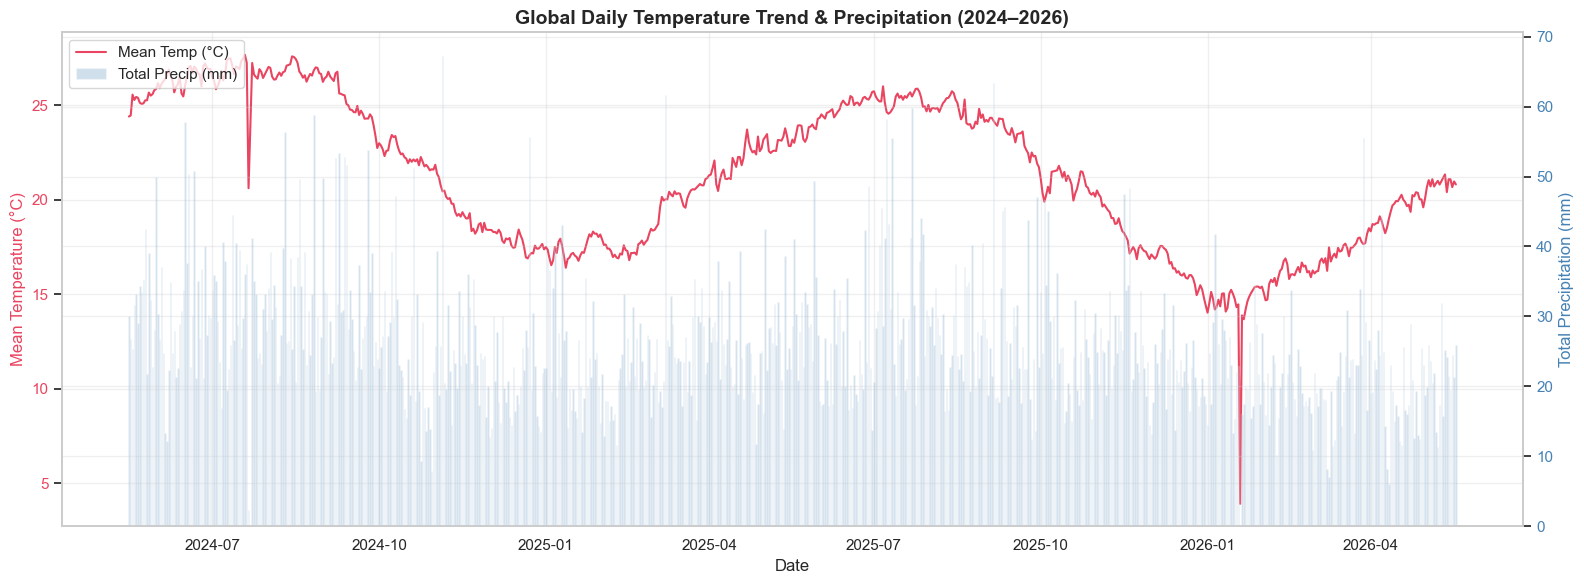

In [18]:
daily_global = (
    df.groupby("date")
      .agg(
          temp_mean=("temperature_celsius", "mean"),
          precip_sum=("precip_mm", "sum"),
      )
      .reset_index()
)
daily_global["date"] = pd.to_datetime(daily_global["date"])

fig, ax1 = plt.subplots(figsize=(16, 6))

color_temp = "#e94560"
ax1.plot(daily_global["date"], daily_global["temp_mean"], color=color_temp, linewidth=1.5, label="Mean Temp (°C)")
ax1.set_ylabel("Mean Temperature (°C)", color=color_temp)
ax1.tick_params(axis="y", labelcolor=color_temp)

ax2 = ax1.twinx()
ax2.bar(daily_global["date"], daily_global["precip_sum"], alpha=0.25, color="steelblue", width=0.8, label="Total Precip (mm)")
ax2.set_ylabel("Total Precipitation (mm)", color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title("Global Daily Temperature Trend & Precipitation (2024–2026)", fontsize=14, fontweight="bold")
ax1.set_xlabel("Date")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_global_daily_trend.png", dpi=100, bbox_inches="tight")
plt.show()


### 4.7 Anomaly Detection with Isolation Forest

In [19]:
ANOM_FEATURES = ["temperature_celsius", "humidity", "wind_mph", "pressure_mb", "precip_mm", "uv_index"]
X_anom = df[ANOM_FEATURES].fillna(df[ANOM_FEATURES].median())

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42,
    n_jobs=-1,
)
df["anomaly"] = iso.fit_predict(X_anom) == -1
n_anomalies = df["anomaly"].sum()
print(f"Anomalies detected: {n_anomalies:,} ({n_anomalies/len(df)*100:.2f}%)")


Anomalies detected: 2,837 (2.00%)


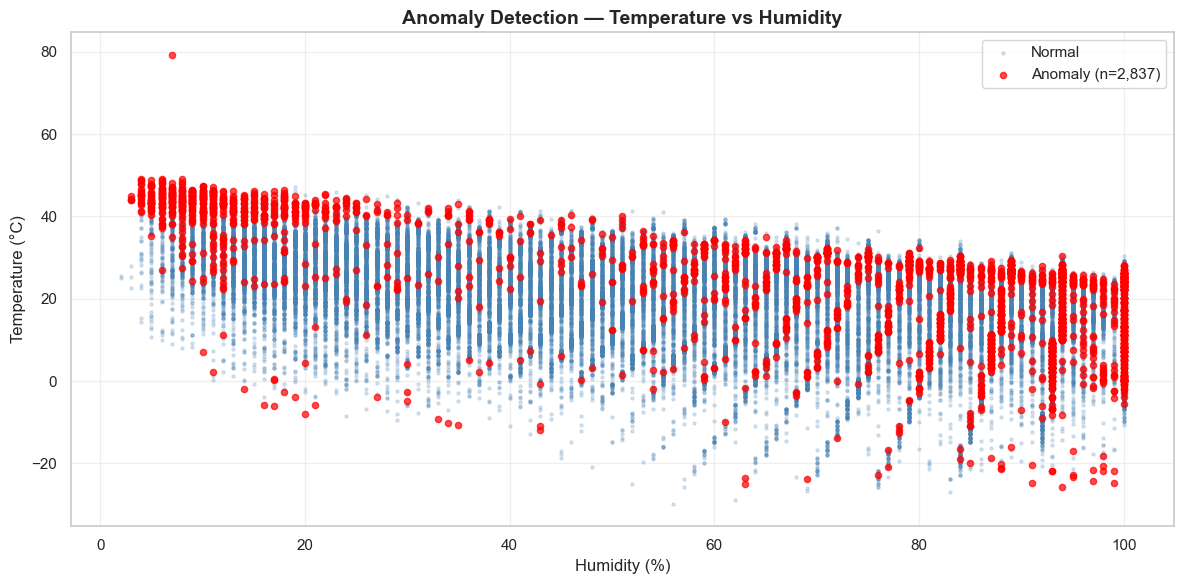


Top 10 most anomalous records:


,location_name,country,last_updated,temperature_celsius,humidity,wind_mph,pressure_mb,precip_mm
103,'S Gravenjansdijk,Belgium,2024-09-27 12:00:00,13.3,77,24.2,994.0,1.32
106,'S Gravenjansdijk,Belgium,2024-09-30 11:30:00,12.3,94,18.3,1008.0,1.94
162,'S Gravenjansdijk,Belgium,2024-11-25 09:45:00,11.1,100,21.9,1000.0,1.06
174,'S Gravenjansdijk,Belgium,2024-12-07 11:30:00,10.1,76,26.2,992.0,0.08
186,'S Gravenjansdijk,Belgium,2024-12-19 11:30:00,6.7,88,22.8,1003.0,1.43
189,'S Gravenjansdijk,Belgium,2024-12-22 11:15:00,5.8,66,25.1,1002.0,0.37
203,'S Gravenjansdijk,Belgium,2025-01-05 10:45:00,3.2,100,14.8,993.0,1.36
204,'S Gravenjansdijk,Belgium,2025-01-06 11:30:00,12.0,77,23.7,979.0,0.00
205,'S Gravenjansdijk,Belgium,2025-01-07 11:15:00,4.3,87,3.6,999.0,1.49
222,'S Gravenjansdijk,Belgium,2025-01-24 11:30:00,7.4,93,27.7,999.0,0.26


In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
normal  = df[~df["anomaly"]]
outlier = df[ df["anomaly"]]

ax.scatter(normal["humidity"],  normal["temperature_celsius"],  alpha=0.2, s=5,  c="steelblue", label="Normal")
ax.scatter(outlier["humidity"], outlier["temperature_celsius"], alpha=0.7, s=20, c="red",       label=f"Anomaly (n={len(outlier):,})")

ax.set_xlabel("Humidity (%)")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Anomaly Detection — Temperature vs Humidity", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_anomaly_detection.png", dpi=100, bbox_inches="tight")
plt.show()

print("\nTop 10 most anomalous records:")
display(
    outlier[["location_name", "country", "last_updated",
             "temperature_celsius", "humidity", "wind_mph", "pressure_mb", "precip_mm"]]
    .head(10)
)


## Section 5 — Spatial Analysis & Geographic Patterns

Global choropleths, interactive bubble maps, and PM2.5 heatmaps reveal geographic clustering of weather and air quality.

### 5.1 Choropleth — average temperature per country

In [21]:
country_stats = (
    df.groupby("country")
      .agg(
          avg_temp=("temperature_celsius", "mean"),
          avg_humidity=("humidity", "mean"),
          avg_pm25=("air_quality_PM2.5", "mean"),
          lat=("latitude", "first"),
          lon=("longitude", "first"),
      )
      .reset_index()
)

fig = px.choropleth(
    country_stats,
    locations="country",
    locationmode="country names",
    color="avg_temp",
    color_continuous_scale="RdYlBu_r",
    title="Average Temperature by Country (2024–2026)",
    labels={"avg_temp": "Avg Temp (°C)"},
)
fig.update_layout(width=1000, height=550, coloraxis_colorbar=dict(title="°C"))
fig.show()


### 5.2 Folium bubble map — 257 locations

In [22]:
location_stats = (
    df.groupby("location_name")
      .agg(
          avg_temp=("temperature_celsius", "mean"),
          lat=("latitude", "first"),
          lon=("longitude", "first"),
          country=("country", "first"),
      )
      .reset_index()
)

m = folium.Map(location=[20, 0], zoom_start=2, tiles="CartoDB positron")

for _, row in location_stats.iterrows():
    color = "crimson" if row["avg_temp"] > 25 else "steelblue"
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=4,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['location_name']}</b><br>{row['country']}<br>Avg Temp: {row['avg_temp']:.1f}°C",
            max_width=200,
        ),
    ).add_to(m)

map_path = os.path.join(OUT_DIR, "temperature_map.html")
m.save(map_path)
print(f"✅ Bubble map saved → {map_path}")
display(HTML(f'<p>Interactive map saved to <code>{map_path}</code>. Open in a browser to explore.</p>'))


✅ Bubble map saved → outputs/temperature_map.html


### 5.3 Folium HeatMap — PM2.5 air quality

In [23]:
pm_data = df[["latitude", "longitude", "air_quality_PM2.5"]].dropna()

m2 = folium.Map(location=[20, 0], zoom_start=2)
HeatMap(
    data=pm_data[["latitude", "longitude", "air_quality_PM2.5"]].values.tolist(),
    radius=12,
    blur=8,
    max_zoom=8,
    min_opacity=0.3,
).add_to(m2)

pm_path = os.path.join(OUT_DIR, "pm25_heatmap.html")
m2.save(pm_path)
print(f"✅ PM2.5 heatmap saved → {pm_path}")
display(HTML(f'<p>PM2.5 heatmap saved to <code>{pm_path}</code>. Open in a browser to explore.</p>'))


✅ PM2.5 heatmap saved → outputs/pm25_heatmap.html


### 5.4 Box plots — 6 weather metrics by continent

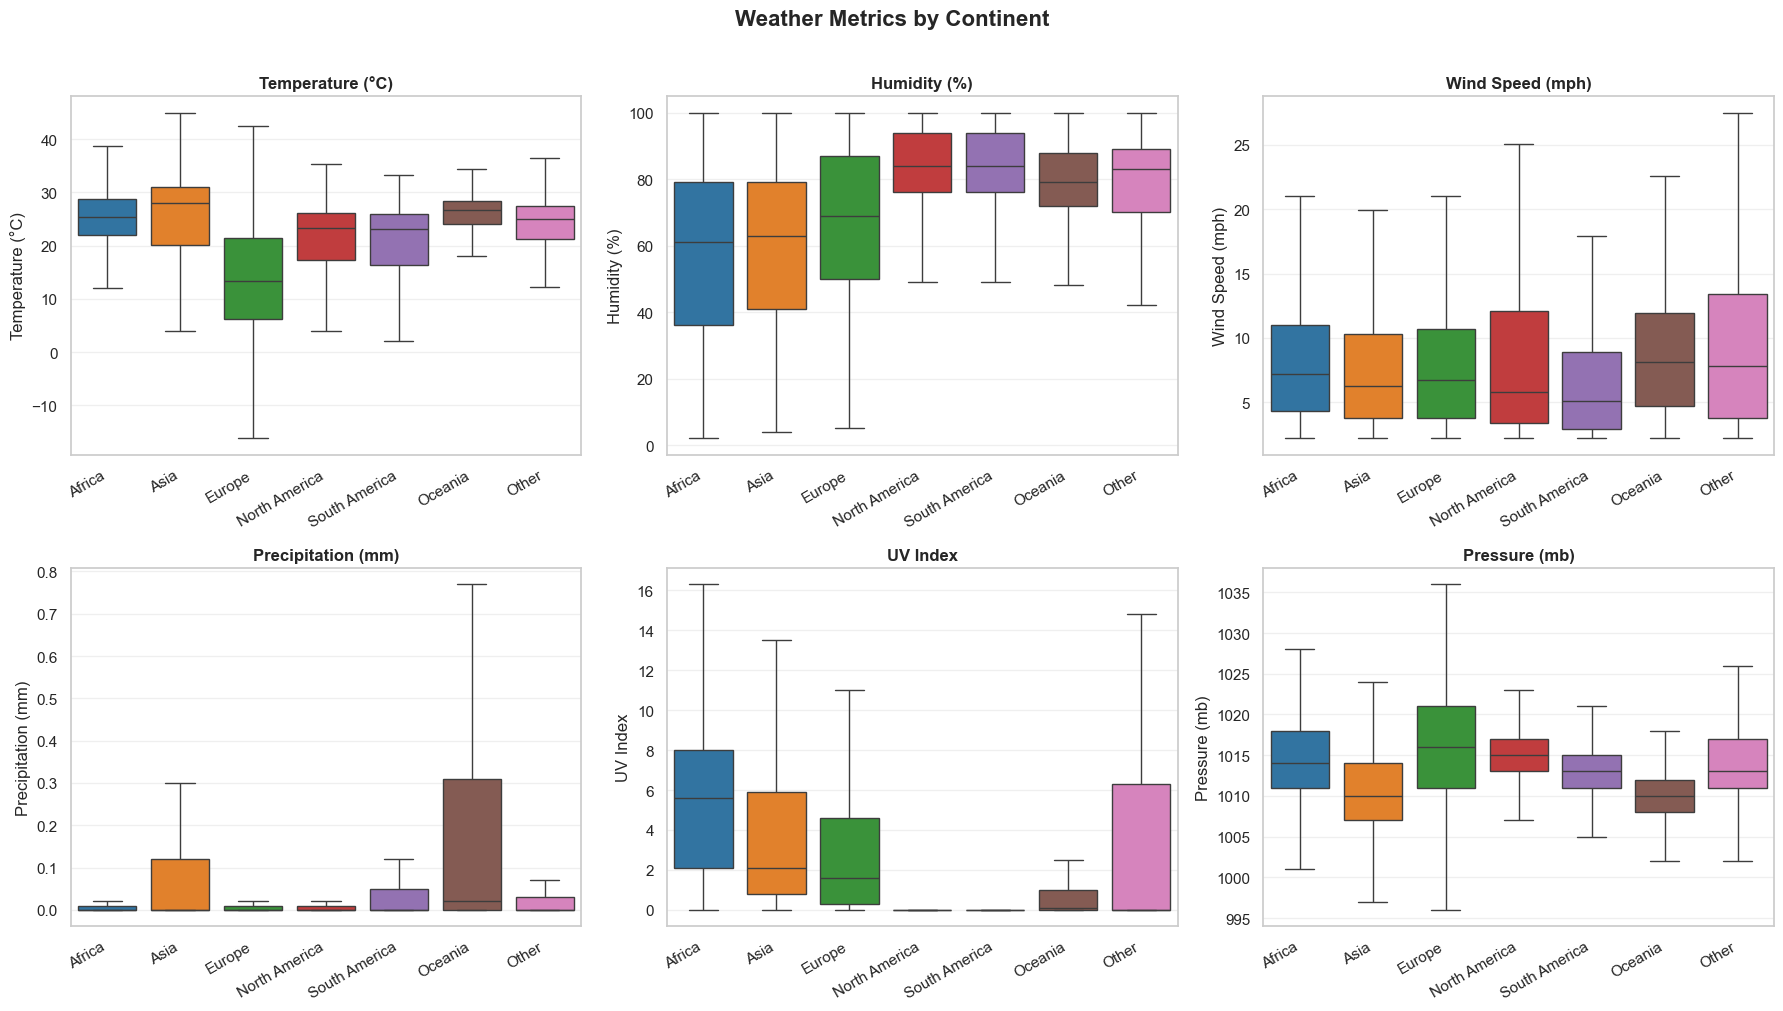

In [24]:
CONTINENT_METRICS = [
    ("temperature_celsius", "Temperature (°C)"),
    ("humidity",            "Humidity (%)"),
    ("wind_mph",            "Wind Speed (mph)"),
    ("precip_mm",           "Precipitation (mm)"),
    ("uv_index",            "UV Index"),
    ("pressure_mb",         "Pressure (mb)"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
continent_order = ["Africa", "Asia", "Europe", "North America", "South America", "Oceania", "Other"]

for ax, (col, label) in zip(axes, CONTINENT_METRICS):
    valid_continents = [c for c in continent_order if c in df["continent"].unique()]
    sns.boxplot(
        data=df[df["continent"].isin(valid_continents)],
        x="continent", y=col,
        order=valid_continents,
        palette="tab10",
        ax=ax,
        showfliers=False,
    )
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

plt.suptitle("Weather Metrics by Continent", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_metrics_by_continent.png", dpi=100, bbox_inches="tight")
plt.show()


### 5.5 Top 10 hottest and coldest countries

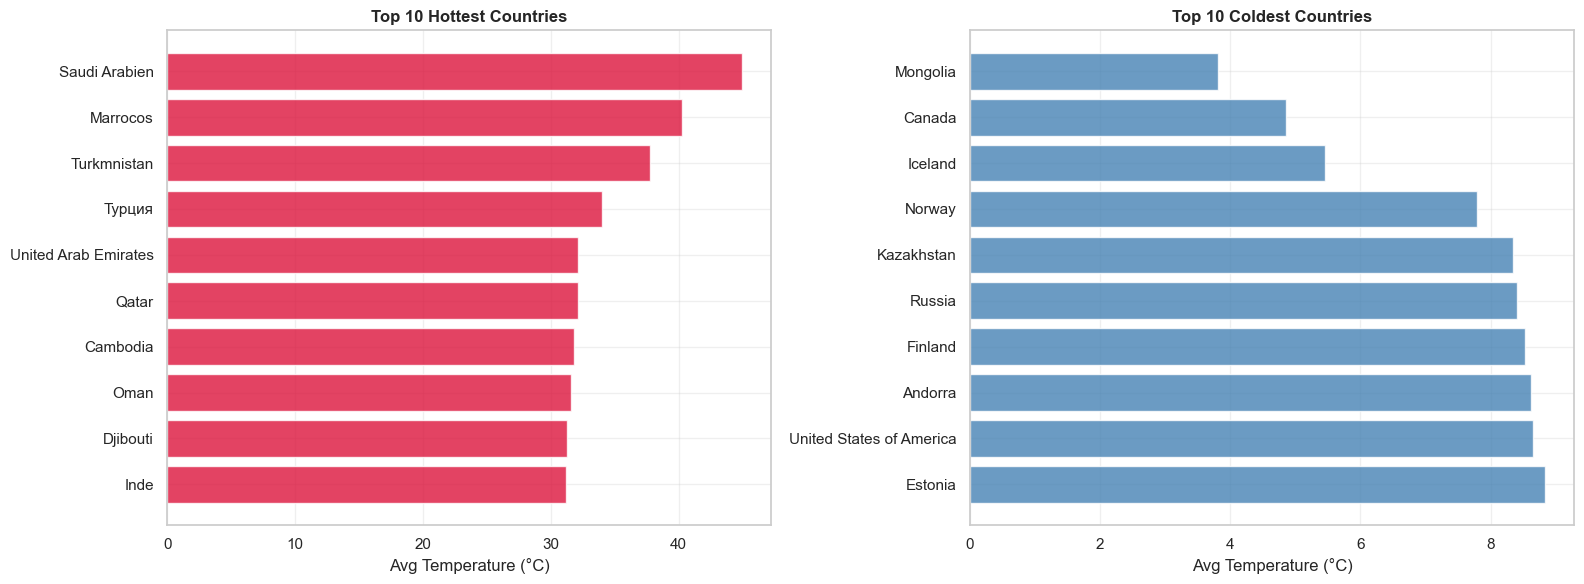

In [25]:
top10_hot  = country_stats.nlargest(10,  "avg_temp")
top10_cold = country_stats.nsmallest(10, "avg_temp")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top10_hot["country"],  top10_hot["avg_temp"],  color="crimson",   alpha=0.8)
axes[0].set_title("Top 10 Hottest Countries",  fontweight="bold")
axes[0].set_xlabel("Avg Temperature (°C)")
axes[0].invert_yaxis()

axes[1].barh(top10_cold["country"], top10_cold["avg_temp"], color="steelblue", alpha=0.8)
axes[1].set_title("Top 10 Coldest Countries", fontweight="bold")
axes[1].set_xlabel("Avg Temperature (°C)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_hottest_coldest_countries.png", dpi=100, bbox_inches="tight")
plt.show()


## Section 6 — Climate Analysis (Long-term Patterns)

Focus on 6 major cities: Tokyo, London, Cairo, São Paulo, Sydney, and Mumbai.
We examine monthly trends, rolling averages, seasonal decomposition, and year-over-year comparisons.

In [26]:
# ── Identify available city names ────────────────────────────
DESIRED_CITIES = ["Tokyo", "London", "Cairo", "Sao Paulo", "Sydney", "Mumbai"]
available_locations = df["location_name"].unique()

FOCUS_CITIES = [c for c in DESIRED_CITIES if c in available_locations]

# Fallbacks for alternate spellings
CITY_ALIASES = {
    "Sao Paulo": ["São Paulo", "Sao Paulo"],
    "Mumbai":    ["Mumbai", "Bombay"],
}
for desired, aliases in CITY_ALIASES.items():
    if desired not in FOCUS_CITIES:
        for alias in aliases:
            if alias in available_locations:
                FOCUS_CITIES.append(alias)
                break

print(f"Focus cities found ({len(FOCUS_CITIES)}): {FOCUS_CITIES}")

city_df = df[df["location_name"].isin(FOCUS_CITIES)].copy()
city_df["year_month"] = city_df["last_updated"].dt.to_period("M")


Focus cities found (4): ['Tokyo', 'London', 'Cairo', 'Sao Paulo']


### 6.2 Monthly mean temperature per city

In [27]:
monthly_city = (
    city_df.groupby(["location_name", "year_month"])["temperature_celsius"]
           .mean()
           .reset_index()
)
monthly_city["year_month_dt"] = monthly_city["year_month"].dt.to_timestamp()

fig = px.line(
    monthly_city,
    x="year_month_dt",
    y="temperature_celsius",
    color="location_name",
    title="Monthly Mean Temperature by City (2024–2026)",
    labels={"temperature_celsius": "Temperature (°C)", "year_month_dt": "Month", "location_name": "City"},
    markers=True,
)
fig.update_layout(width=1000, height=500)
fig.show()


### 6.3 30-day rolling average per city

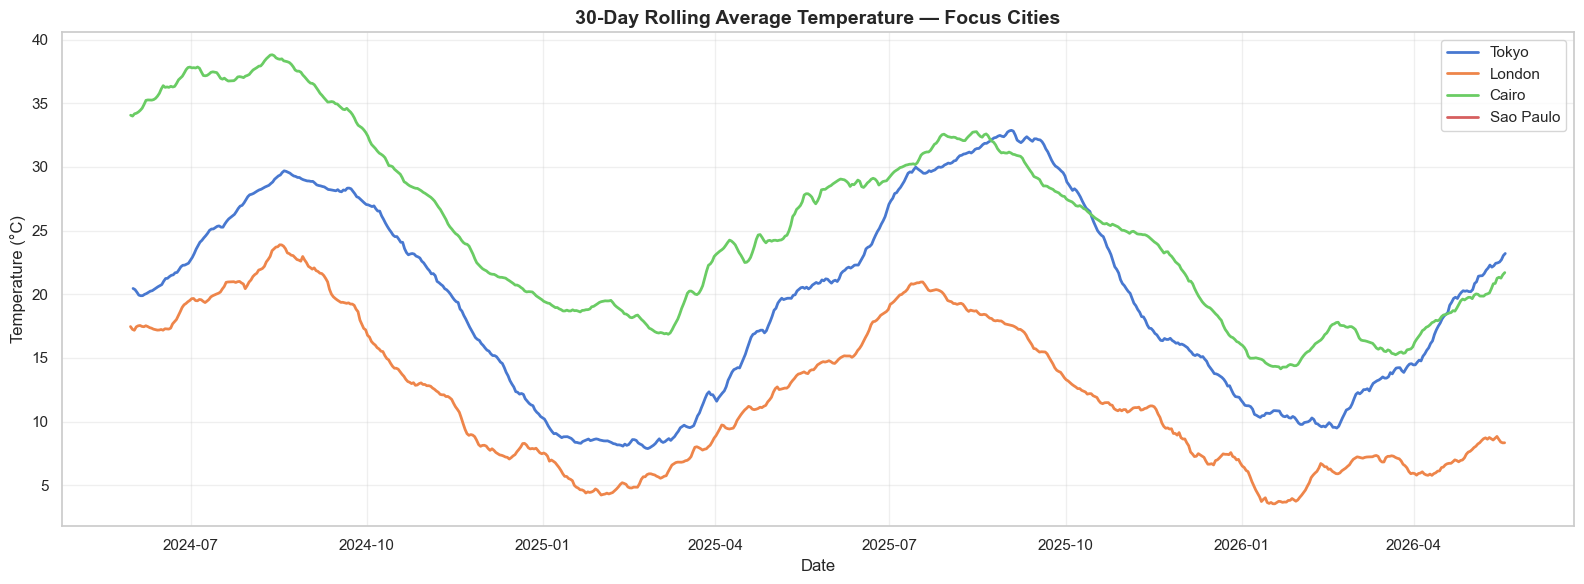

In [28]:
city_df = city_df.sort_values("last_updated")
city_df["temp_rolling_30d"] = (
    city_df.groupby("location_name")["temperature_celsius"]
           .transform(lambda x: x.rolling(30, min_periods=15).mean())
)

fig, ax = plt.subplots(figsize=(16, 6))
for city in FOCUS_CITIES:
    subset = city_df[city_df["location_name"] == city]
    ax.plot(subset["last_updated"], subset["temp_rolling_30d"], label=city, linewidth=2)

ax.set_title("30-Day Rolling Average Temperature — Focus Cities", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_rolling_avg_temp.png", dpi=100, bbox_inches="tight")
plt.show()


### 6.4 Seasonal decomposition — Tokyo daily temperature

Decomposing 'Tokyo' temperature series: 733 daily observations


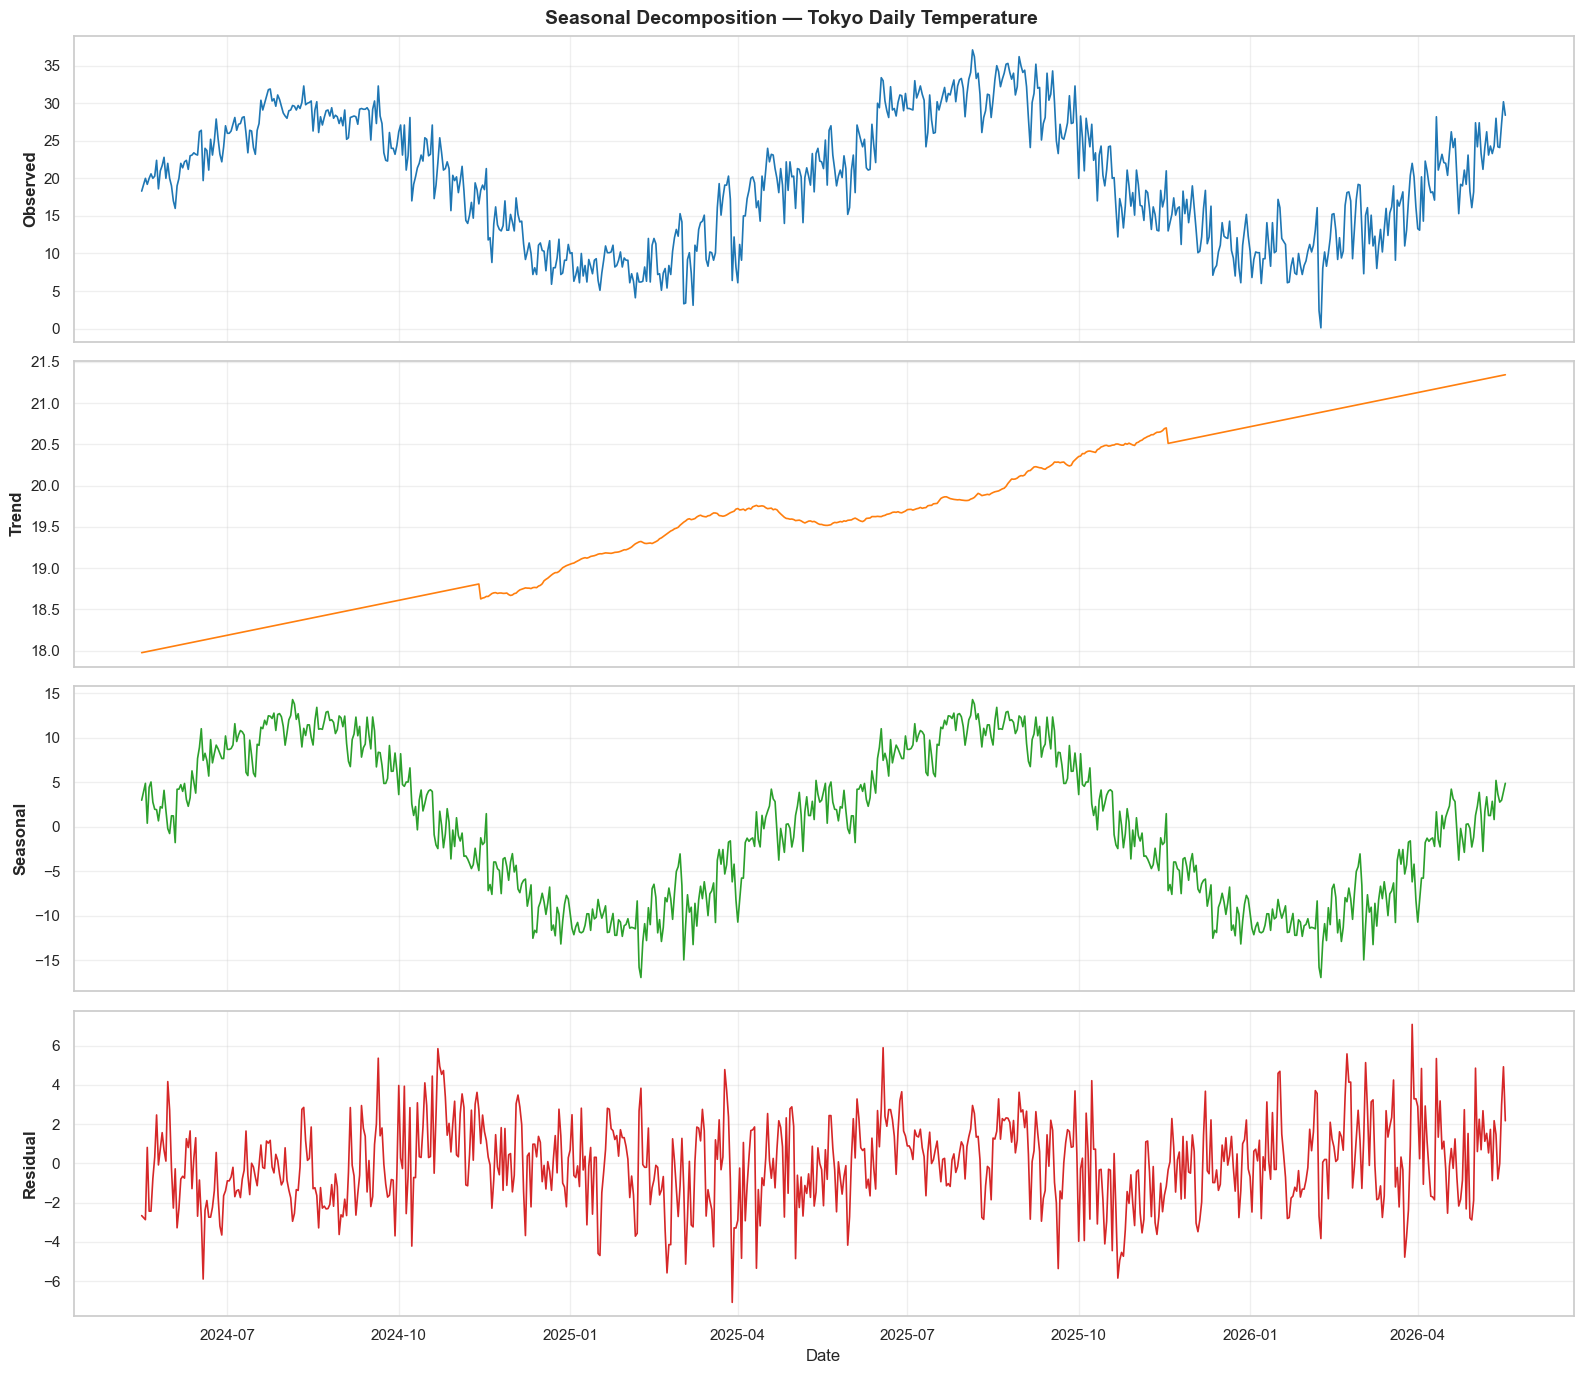

In [29]:
DECOMP_CITY = FOCUS_CITIES[0]  # Tokyo (or first available)

city_ts = (
    city_df[city_df["location_name"] == DECOMP_CITY]
    .set_index("last_updated")["temperature_celsius"]
    .resample("D")
    .mean()
    .interpolate("linear")
)

print(f"Decomposing '{DECOMP_CITY}' temperature series: {len(city_ts)} daily observations")

if len(city_ts) >= 365 * 2:
    result = seasonal_decompose(city_ts, model="additive", period=365, extrapolate_trend="freq")

    fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
    components = [
        (city_ts,          "Observed",  "#1f77b4"),
        (result.trend,     "Trend",     "#ff7f0e"),
        (result.seasonal,  "Seasonal",  "#2ca02c"),
        (result.resid,     "Residual",  "#d62728"),
    ]
    for ax, (data, label, color) in zip(axes, components):
        ax.plot(data, color=color, linewidth=1.2)
        ax.set_ylabel(label, fontweight="bold")
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel("Date")
    fig.suptitle(f"Seasonal Decomposition — {DECOMP_CITY} Daily Temperature", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/10_seasonal_decomposition.png", dpi=100, bbox_inches="tight")
    plt.show()
else:
    print("⚠️  Insufficient data for period=365 decomposition.")


### 6.5 Year-over-year comparison — 2024 vs 2025

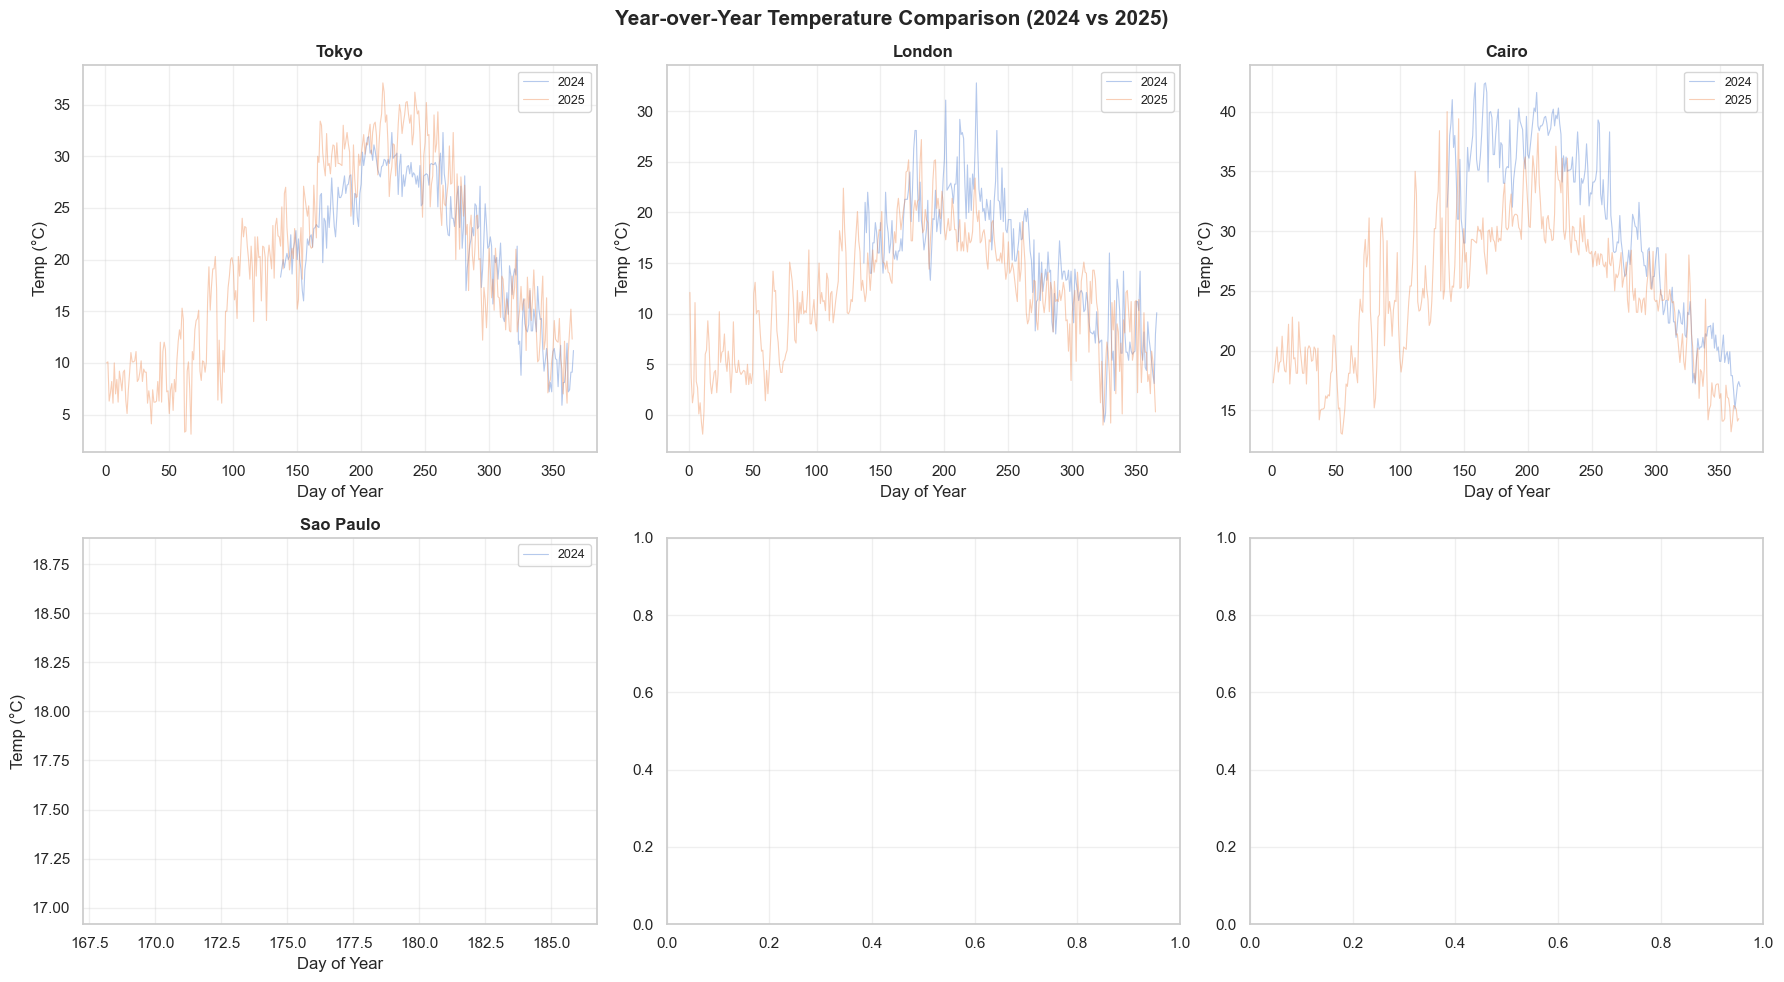

In [30]:
city_yoy = city_df[city_df["last_updated"].dt.year.isin([2024, 2025])].copy()
city_yoy["year"] = city_yoy["last_updated"].dt.year.astype(str)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=False)
axes = axes.flatten()

for ax, city in zip(axes, FOCUS_CITIES[:6]):
    subset = city_yoy[city_yoy["location_name"] == city]
    for year, grp in subset.groupby("year"):
        ax.plot(grp["day_of_year"], grp["temperature_celsius"],
                alpha=0.4, linewidth=0.8, label=year)
    ax.set_title(city, fontweight="bold")
    ax.set_xlabel("Day of Year")
    ax.set_ylabel("Temp (°C)")
    ax.legend(fontsize=9)

plt.suptitle("Year-over-Year Temperature Comparison (2024 vs 2025)", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/11_yoy_comparison.png", dpi=100, bbox_inches="tight")
plt.show()


## Section 7 — Environmental Impact Analysis

Explore the relationship between weather conditions and air quality metrics.

### 7.1 Weather vs Air Quality correlation sub-heatmap

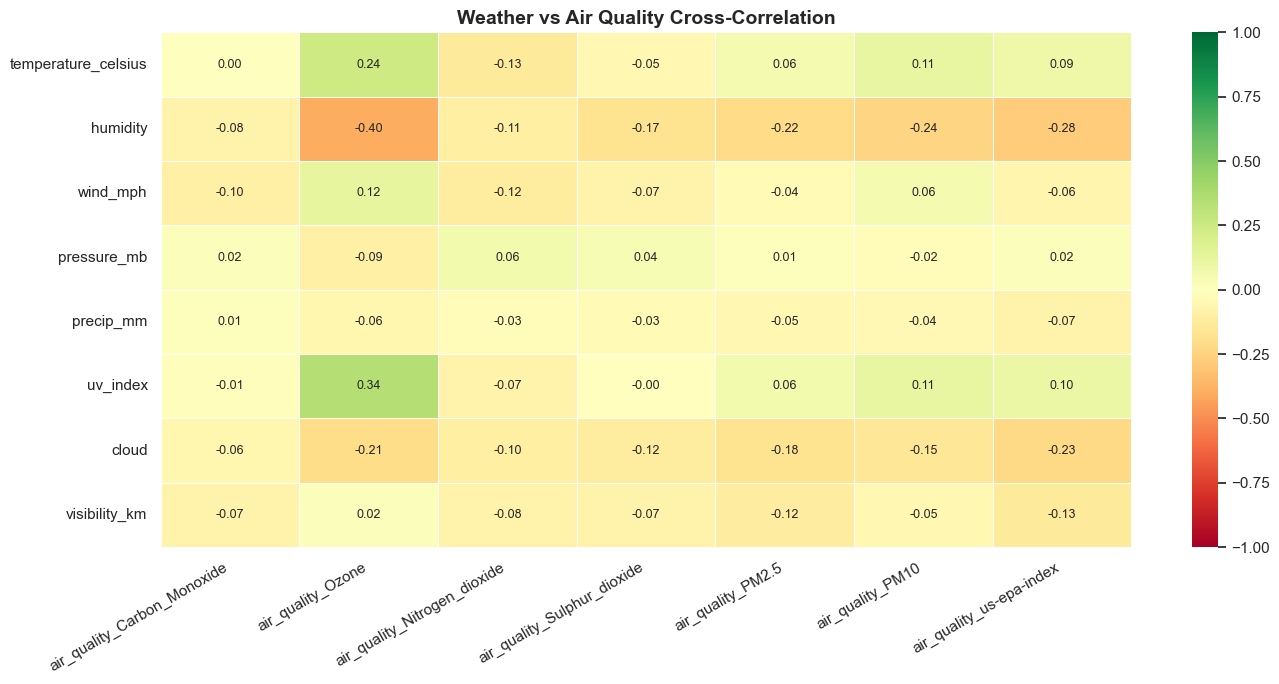

In [31]:
WEATHER_COLS = ["temperature_celsius", "humidity", "wind_mph", "pressure_mb",
                "precip_mm", "uv_index", "cloud", "visibility_km"]
AQ_METRIC_COLS = [
    "air_quality_Carbon_Monoxide", "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide", "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5", "air_quality_PM10",
    "air_quality_us-epa-index",
]

cross_corr = df[WEATHER_COLS + AQ_METRIC_COLS].corr().loc[WEATHER_COLS, AQ_METRIC_COLS]

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    cross_corr, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=-1, vmax=1, linewidths=0.5, ax=ax, annot_kws={"size": 9},
)
ax.set_title("Weather vs Air Quality Cross-Correlation", fontsize=14, fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/12_weather_aq_correlation.png", dpi=100, bbox_inches="tight")
plt.show()


### 7.2 EPA AQI distribution by weather condition

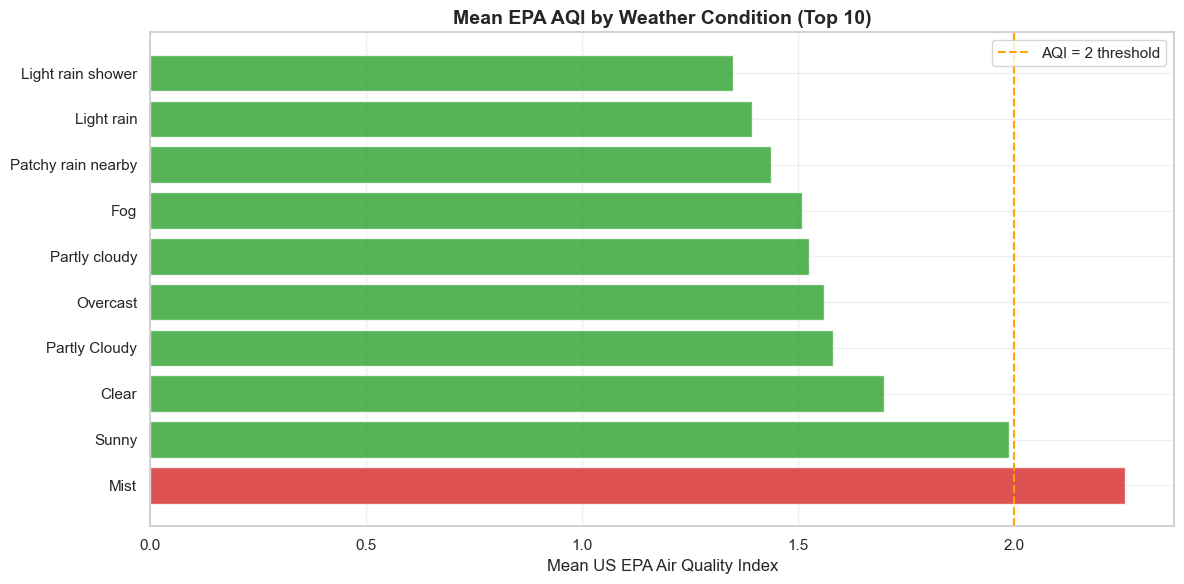

In [32]:
top10_conditions = df["condition_text"].value_counts().head(10).index

epa_by_cond = (
    df[df["condition_text"].isin(top10_conditions)]
      .groupby("condition_text")["air_quality_us-epa-index"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ["#d62728" if v > 2 else "#2ca02c" for v in epa_by_cond["air_quality_us-epa-index"]]
ax.barh(epa_by_cond["condition_text"], epa_by_cond["air_quality_us-epa-index"],
        color=colors, alpha=0.8, edgecolor="white")
ax.axvline(2, color="orange", linestyle="--", label="AQI = 2 threshold")
ax.set_title("Mean EPA AQI by Weather Condition (Top 10)", fontsize=14, fontweight="bold")
ax.set_xlabel("Mean US EPA Air Quality Index")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/13_epa_by_condition.png", dpi=100, bbox_inches="tight")
plt.show()


### 7.3 PM2.5 vs wind speed scatter (expected inverse relationship)

In [33]:
pm_wind = df[["wind_mph", "air_quality_PM2.5", "continent"]].dropna().sample(
    min(5000, len(df)), random_state=42
)

fig = px.scatter(
    pm_wind,
    x="wind_mph",
    y="air_quality_PM2.5",
    color="continent",
    opacity=0.5,
    trendline="lowess",
    trendline_scope="overall",
    title="PM2.5 vs Wind Speed (sample n=5,000) — expected inverse relationship",
    labels={"wind_mph": "Wind Speed (mph)", "air_quality_PM2.5": "PM2.5 (μg/m³)"},
)
fig.update_traces(marker=dict(size=4))
fig.update_layout(width=1000, height=500)
fig.show()


### 7.4 Monthly PM2.5 trend (global mean)

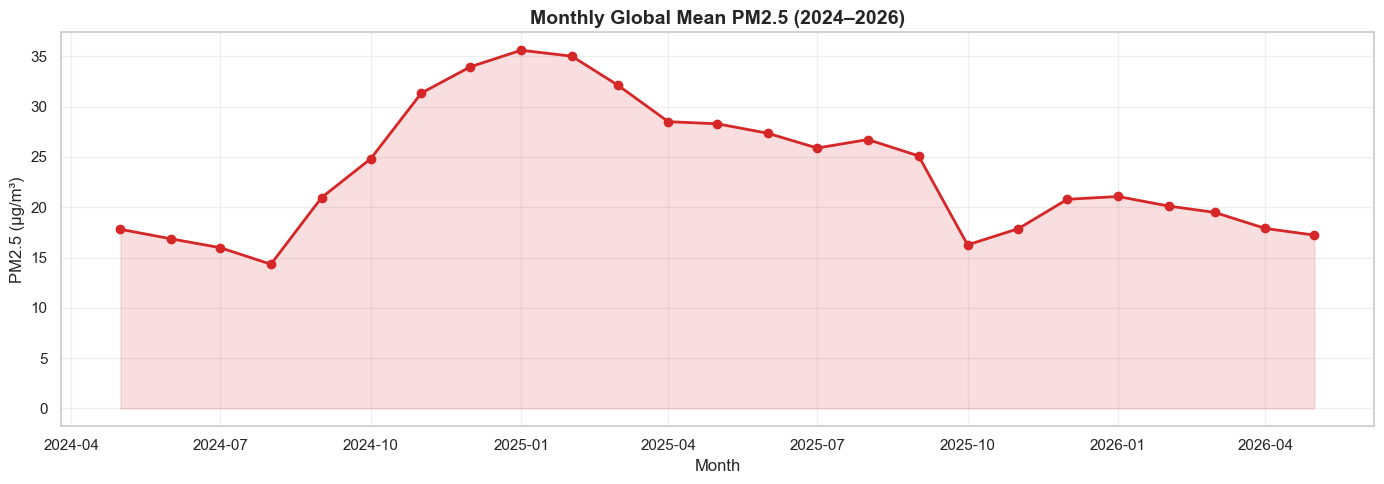

In [34]:
monthly_pm25 = (
    df.assign(month_start=df["last_updated"].dt.to_period("M").dt.to_timestamp())
      .groupby("month_start")["air_quality_PM2.5"]
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_pm25["month_start"], monthly_pm25["air_quality_PM2.5"],
        marker="o", color="#d62728", linewidth=2)
ax.fill_between(monthly_pm25["month_start"], monthly_pm25["air_quality_PM2.5"],
                alpha=0.15, color="#d62728")
ax.set_title("Monthly Global Mean PM2.5 (2024–2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("PM2.5 (μg/m³)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/14_monthly_pm25_trend.png", dpi=100, bbox_inches="tight")
plt.show()


### 7.5 Air quality comparison by continent

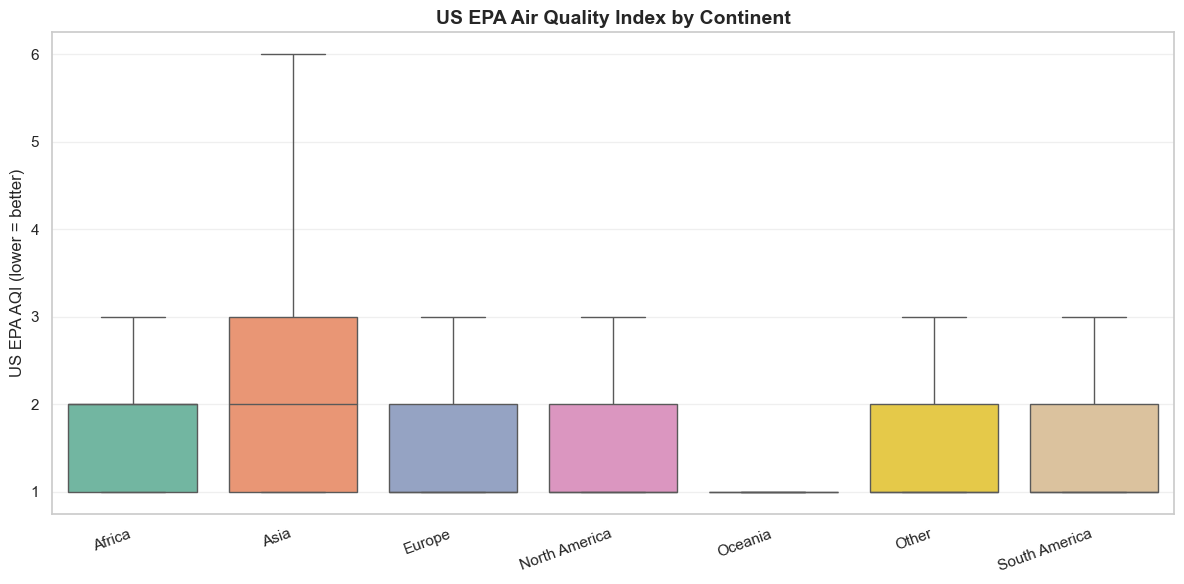

In [35]:
fig, ax = plt.subplots(figsize=(12, 6))
continent_order_aq = (
    df.groupby("continent")["air_quality_us-epa-index"]
      .median()
      .sort_values(ascending=False)
      .index.tolist()
)
sns.boxplot(
    data=df,
    x="continent",
    y="air_quality_us-epa-index",
    order=continent_order_aq,
    palette="Set2",
    ax=ax,
    showfliers=False,
)
ax.set_title("US EPA Air Quality Index by Continent", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("US EPA AQI (lower = better)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/15_aq_by_continent.png", dpi=100, bbox_inches="tight")
plt.show()


## Section 8 — Feature Importance (Random Forest Regressor)

We use a temporal train/test split (pre/post 2026-01-01) to avoid data leakage, then measure each feature's contribution to predicting daily temperature.

In [36]:
FEATURE_COLS = [
    "latitude", "longitude", "month", "day_of_year",
    "humidity", "pressure_mb", "wind_mph", "precip_mm",
    "uv_index", "cloud", "visibility_km", "moon_phase_ord",
    "air_quality_PM2.5", "air_quality_Ozone",
]
TARGET = "temperature_celsius"

rf_df = df[FEATURE_COLS + [TARGET, "last_updated"]].dropna()

CUTOFF = pd.Timestamp("2026-01-01")
train_rf = rf_df[rf_df["last_updated"] < CUTOFF]
test_rf  = rf_df[rf_df["last_updated"] >= CUTOFF]

X_train = train_rf[FEATURE_COLS]
y_train = train_rf[TARGET]
X_test  = test_rf[FEATURE_COLS]
y_test  = test_rf[TARGET]

print(f"Train : {len(X_train):,} rows (before 2026-01-01)")
print(f"Test  : {len(X_test):,}  rows (2026-01-01 and after)")


Train : 115,324 rows (before 2026-01-01)
Test  : 26,519  rows (2026-01-01 and after)


In [37]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae  = skmetrics.mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(skmetrics.mean_squared_error(y_test, y_pred))
r2   = skmetrics.r2_score(y_test, y_pred)

print(f"Test MAE  : {mae:.3f} °C")
print(f"Test RMSE : {rmse:.3f} °C")
print(f"Test R²   : {r2:.4f}")


Test MAE  : 2.745 °C
Test RMSE : 3.953 °C
Test R²   : 0.8648


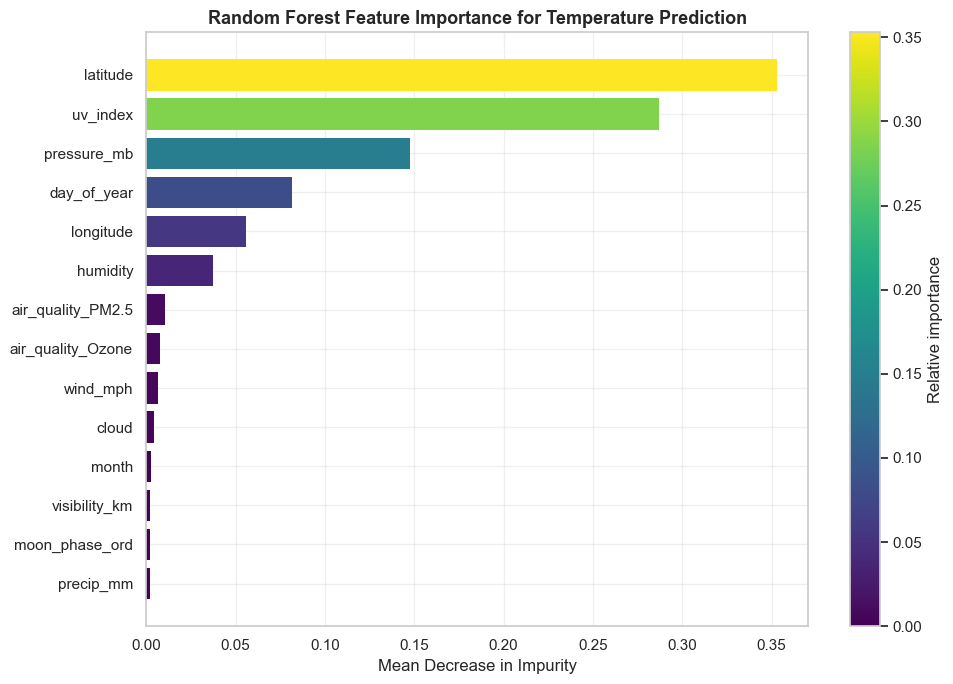

In [38]:
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
cmap_vals = importances.values / importances.values.max()
colors = cm.viridis(cmap_vals)
ax.barh(importances.index, importances.values, color=colors, edgecolor="none")
ax.set_title("Random Forest Feature Importance for Temperature Prediction",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mean Decrease in Impurity")
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=0, vmax=importances.max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Relative importance")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/16_feature_importance.png", dpi=100, bbox_inches="tight")
plt.show()


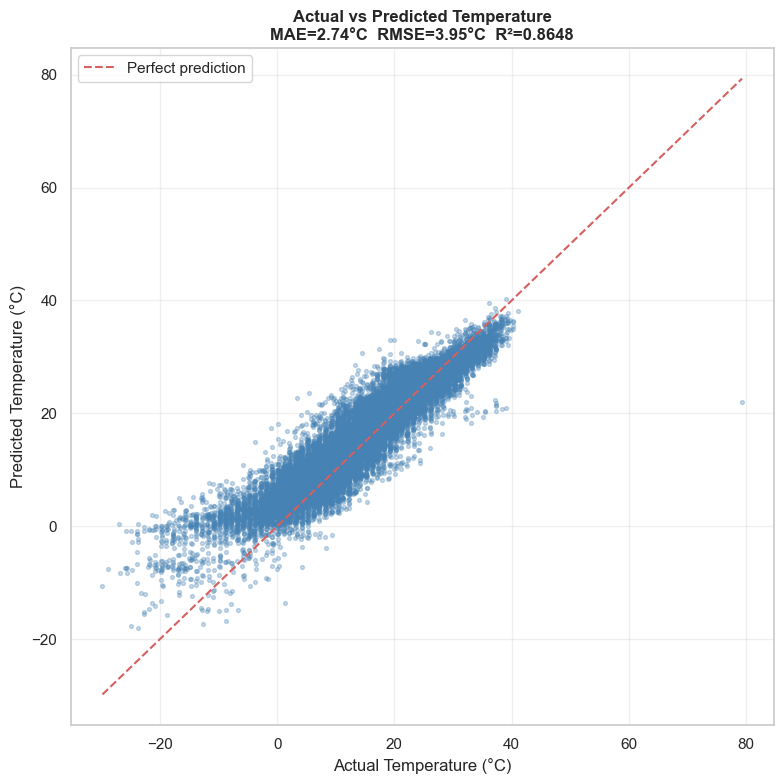

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred, alpha=0.3, s=8, c="steelblue")
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Temperature (°C)")
ax.set_ylabel("Predicted Temperature (°C)")
ax.set_title(f"Actual vs Predicted Temperature\nMAE={mae:.2f}°C  RMSE={rmse:.2f}°C  R²={r2:.4f}",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/17_actual_vs_predicted.png", dpi=100, bbox_inches="tight")
plt.show()


## Section 9 — Time Series Forecasting

We apply three forecasting methods:
1. **Prophet** (Facebook/Meta) — handles daily seasonality, changepoints, and missing values gracefully.
2. **SARIMA(2,1,2)×(1,1,1,12)** — classical statsmodels approach on monthly-resampled data.
3. **Inverse-MAE Weighted Ensemble** — combines both forecasts on the overlapping monthly test window.

> **Why monthly SARIMA?** `period=365` for a daily SARIMA would require estimating 365 seasonal lag coefficients, which is computationally infeasible and numerically unstable. Resampling to monthly (period=12) is the standard approach.

### 9.1 Prepare Tokyo daily temperature series

In [40]:
TS_CITY = FOCUS_CITIES[0]  # Tokyo or first available
CUTOFF_DATE = pd.Timestamp("2026-03-19")  # last 60 days as test

city_ts = (
    df[df["location_name"] == TS_CITY]
    .set_index("last_updated")["temperature_celsius"]
    .resample("D")
    .mean()
    .interpolate("linear")
)

train_ts = city_ts[city_ts.index <  CUTOFF_DATE]
test_ts  = city_ts[city_ts.index >= CUTOFF_DATE]

print(f"City         : {TS_CITY}")
print(f"Train period : {train_ts.index.min().date()} → {train_ts.index.max().date()} ({len(train_ts)} days)")
print(f"Test period  : {test_ts.index.min().date()} → {test_ts.index.max().date()} ({len(test_ts)} days)")


City         : Tokyo
Train period : 2024-05-16 → 2026-03-18 (672 days)
Test period  : 2026-03-19 → 2026-05-18 (61 days)


### 9.2 Prophet forecast

In [41]:
prophet_df = train_ts.reset_index().rename(
    columns={"last_updated": "ds", "temperature_celsius": "y"}
)

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05,
)
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=len(test_ts) + 30, freq="D")
forecast = prophet_model.predict(future)

print(f"Forecast DataFrame shape: {forecast.shape}")
forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)


01:38:11 - cmdstanpy - INFO - Chain [1] start processing


01:38:11 - cmdstanpy - INFO - Chain [1] done processing


Forecast DataFrame shape: (763, 16)


,ds,yhat,yhat_lower,yhat_upper
753,2026-06-08,25.578235,21.917295,29.329064
754,2026-06-09,25.892380,22.255261,29.483754
755,2026-06-10,26.221615,22.826137,29.813183
756,2026-06-11,26.562599,22.918215,30.151310
757,2026-06-12,26.911713,23.406371,30.707950
758,2026-06-13,27.265142,23.775486,31.089113
759,2026-06-14,27.618958,23.707626,31.240397
760,2026-06-15,27.969210,24.506675,31.293567
761,2026-06-16,28.312014,24.699482,31.867098
762,2026-06-17,28.643644,25.076574,32.346229


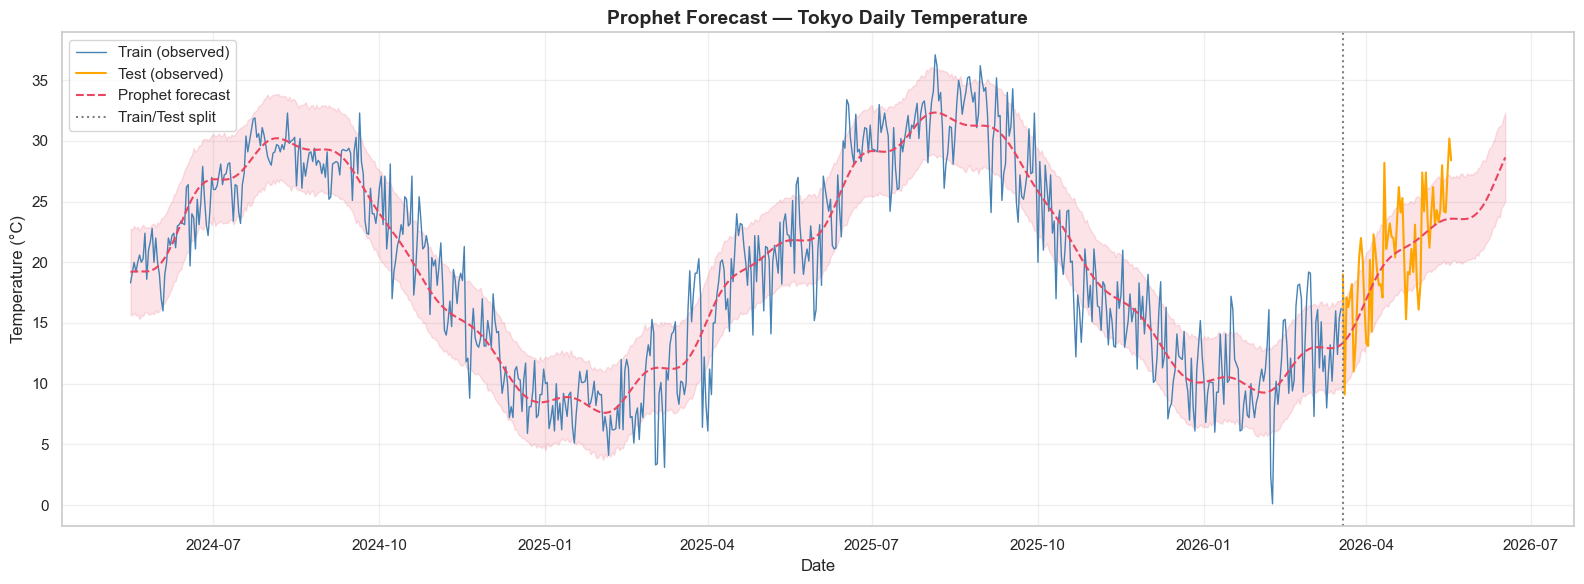

In [42]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(train_ts.index, train_ts.values, color="steelblue", linewidth=1, label="Train (observed)")
ax.plot(test_ts.index,  test_ts.values,  color="orange",    linewidth=1.5, label="Test (observed)")

fc_plot = forecast.set_index("ds")
ax.plot(fc_plot.index, fc_plot["yhat"],       color="#e94560", linewidth=1.5, linestyle="--", label="Prophet forecast")
ax.fill_between(fc_plot.index, fc_plot["yhat_lower"], fc_plot["yhat_upper"], alpha=0.15, color="#e94560")
ax.axvline(CUTOFF_DATE, color="grey", linestyle=":", linewidth=1.5, label="Train/Test split")
ax.set_title(f"Prophet Forecast — {TS_CITY} Daily Temperature", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/18_prophet_forecast.png", dpi=100, bbox_inches="tight")
plt.show()


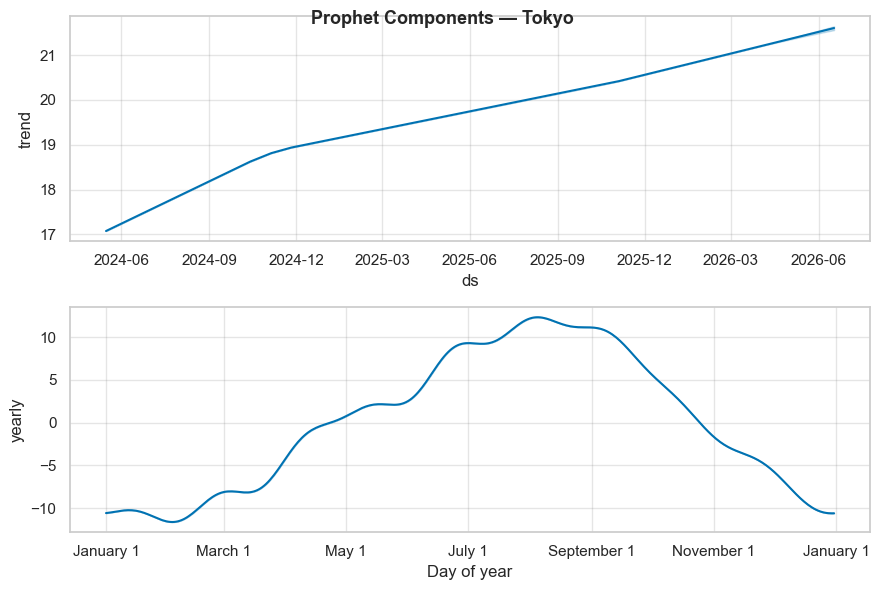

In [43]:
# ── Prophet component plots ──────────────────────────────────
fig_comp = prophet_model.plot_components(forecast)
fig_comp.suptitle(f"Prophet Components — {TS_CITY}", fontsize=13, fontweight="bold")
fig_comp.savefig(f"{FIG_DIR}/19_prophet_components.png", dpi=100, bbox_inches="tight")
plt.show()


### 9.3 SARIMA on monthly-resampled data

In [44]:
# Resample to monthly
city_monthly = city_ts.resample("ME").mean()
train_monthly = city_monthly[city_monthly.index < CUTOFF_DATE]
test_monthly  = city_monthly[city_monthly.index >= CUTOFF_DATE]

print(f"Monthly train: {len(train_monthly)} months")
print(f"Monthly test : {len(test_monthly)} months")

if len(train_monthly) >= 14:
    sarima_model = SARIMAX(
        train_monthly,
        order=(2, 1, 2),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    sarima_fit = sarima_model.fit(disp=False)
    print("\nSARIMA fitted successfully.")
    print(sarima_fit.summary().tables[0])
else:
    print("⚠️  Not enough monthly data for SARIMA. At least 14 months required.")
    sarima_fit = None


Monthly train: 22 months
Monthly test : 3 months

SARIMA fitted successfully.
                                      SARIMAX Results                                       
Dep. Variable:                  temperature_celsius   No. Observations:                   22
Model:             SARIMAX(2, 1, 2)x(1, 1, [1], 12)   Log Likelihood                   0.000
Date:                              Tue, 19 May 2026   AIC                             14.000
Time:                                      01:38:12   BIC                                nan
Sample:                                  05-31-2024   HQIC                               nan
                                       - 02-28-2026                                         
Covariance Type:                                opg                                         


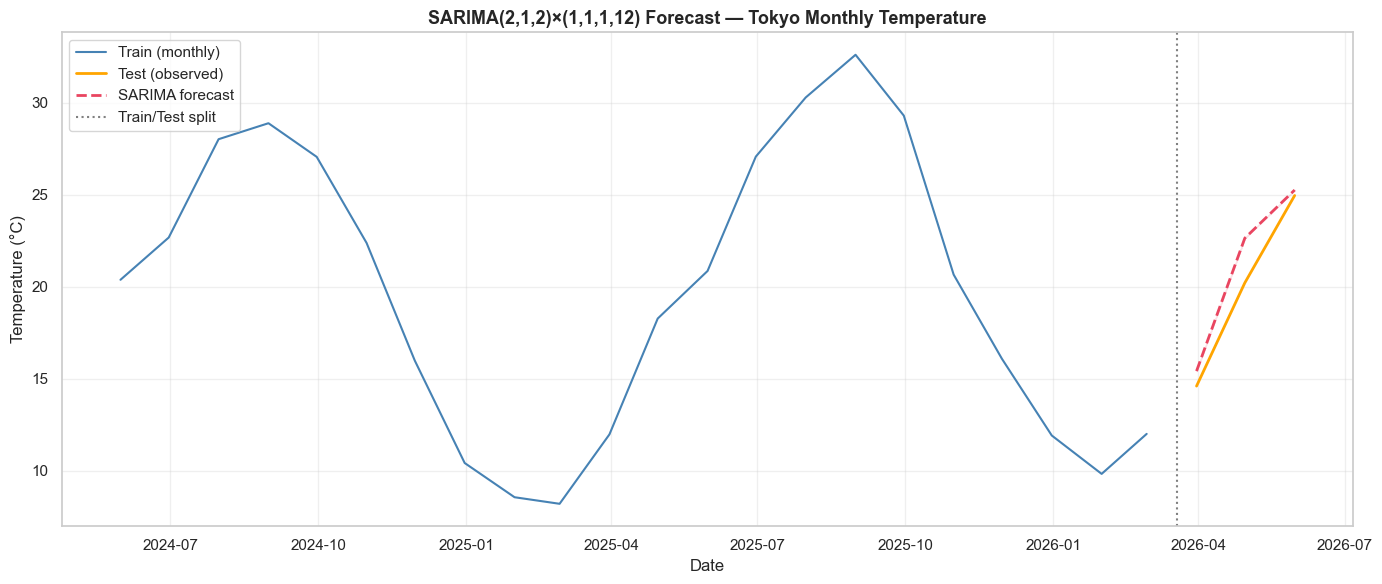

In [45]:
if sarima_fit is not None:
    sarima_forecast = sarima_fit.get_forecast(steps=max(len(test_monthly), 3))
    sarima_pred = sarima_forecast.predicted_mean
    sarima_ci   = sarima_forecast.conf_int()

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(train_monthly.index, train_monthly.values, color="steelblue", label="Train (monthly)")
    ax.plot(test_monthly.index,  test_monthly.values,  color="orange",    linewidth=2, label="Test (observed)")
    ax.plot(sarima_pred.index,   sarima_pred.values,   color="#e94560",   linestyle="--", linewidth=2, label="SARIMA forecast")
    ax.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], alpha=0.15, color="#e94560")
    ax.axvline(CUTOFF_DATE, color="grey", linestyle=":", linewidth=1.5, label="Train/Test split")
    ax.set_title(f"SARIMA(2,1,2)×(1,1,1,12) Forecast — {TS_CITY} Monthly Temperature",
                 fontsize=13, fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Temperature (°C)")
    ax.legend()
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/20_sarima_forecast.png", dpi=100, bbox_inches="tight")
    plt.show()


### 9.4 Inverse-MAE weighted ensemble

Prophet weight  : 0.574  (MAE=0.88°C)
SARIMA  weight  : 0.426  (MAE=1.18°C)
Ensemble MAE    : 0.660°C
Ensemble RMSE   : 0.755°C


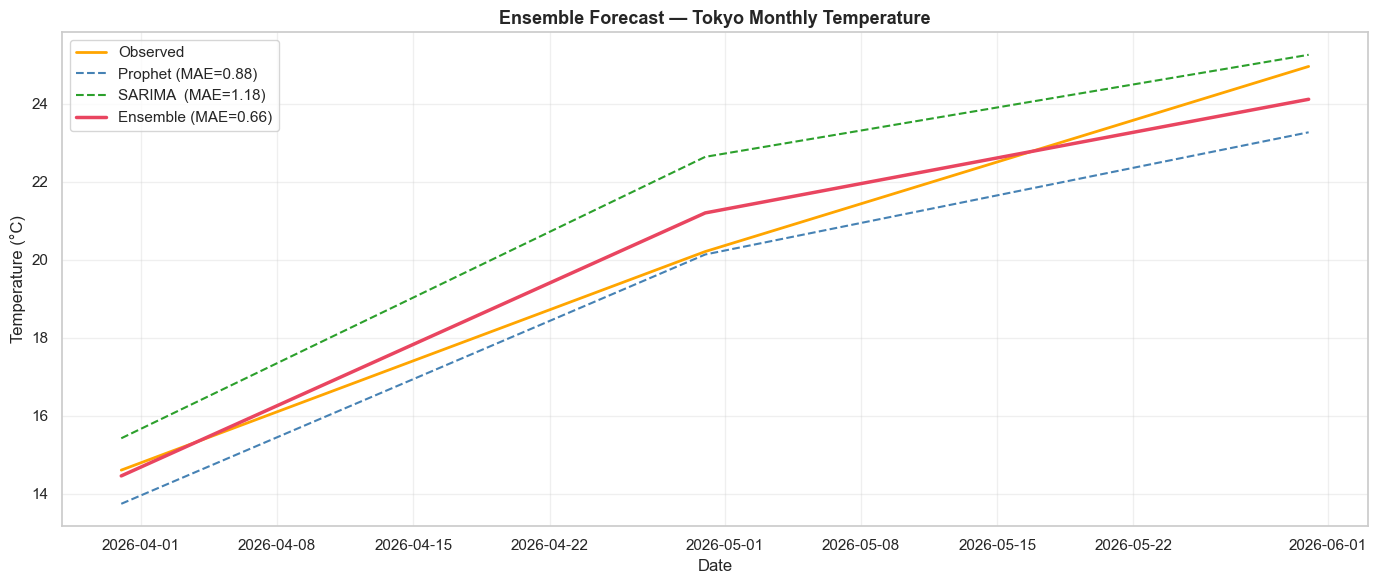

In [46]:
if sarima_fit is not None and len(test_monthly) >= 1:
    # Align Prophet forecast to monthly test period
    prophet_monthly = (
        forecast.set_index("ds")["yhat"]
                .resample("ME")
                .mean()
                .reindex(test_monthly.index)
    )

    sarima_monthly = sarima_pred.reindex(test_monthly.index)

    # Drop months with NaN in either forecast
    valid_idx = prophet_monthly.dropna().index.intersection(sarima_monthly.dropna().index)

    if len(valid_idx) > 0:
        p_aligned = prophet_monthly.loc[valid_idx]
        s_aligned = sarima_monthly.loc[valid_idx]
        y_aligned = test_monthly.loc[valid_idx]

        mae_p = skmetrics.mean_absolute_error(y_aligned, p_aligned)
        mae_s = skmetrics.mean_absolute_error(y_aligned, s_aligned)

        # Inverse-MAE weights (lower MAE → higher weight)
        w_p = (1 / (mae_p + 1e-9))
        w_s = (1 / (mae_s + 1e-9))
        w_total = w_p + w_s
        w_p /= w_total
        w_s /= w_total

        ensemble_pred = w_p * p_aligned + w_s * s_aligned

        print(f"Prophet weight  : {w_p:.3f}  (MAE={mae_p:.2f}°C)")
        print(f"SARIMA  weight  : {w_s:.3f}  (MAE={mae_s:.2f}°C)")

        mae_e  = skmetrics.mean_absolute_error(y_aligned, ensemble_pred)
        rmse_e = np.sqrt(skmetrics.mean_squared_error(y_aligned, ensemble_pred))
        print(f"Ensemble MAE    : {mae_e:.3f}°C")
        print(f"Ensemble RMSE   : {rmse_e:.3f}°C")

        fig, ax = plt.subplots(figsize=(14, 6))
        ax.plot(y_aligned.index,        y_aligned.values,       color="orange",   linewidth=2, label="Observed")
        ax.plot(p_aligned.index,        p_aligned.values,       color="steelblue",linestyle="--", label=f"Prophet (MAE={mae_p:.2f})")
        ax.plot(s_aligned.index,        s_aligned.values,       color="#2ca02c",  linestyle="--", label=f"SARIMA  (MAE={mae_s:.2f})")
        ax.plot(ensemble_pred.index,    ensemble_pred.values,   color="#e94560",  linewidth=2.5, label=f"Ensemble (MAE={mae_e:.2f})")
        ax.set_title(f"Ensemble Forecast — {TS_CITY} Monthly Temperature", fontsize=13, fontweight="bold")
        ax.set_xlabel("Date")
        ax.set_ylabel("Temperature (°C)")
        ax.legend()
        plt.tight_layout()
        plt.savefig(f"{FIG_DIR}/21_ensemble_forecast.png", dpi=100, bbox_inches="tight")
        plt.show()
    else:
        print("⚠️  No overlapping months to compare. Skipping ensemble plot.")
        mae_p = mae_s = mae_e = rmse_e = float("nan")
        w_p = w_s = 0.5
else:
    print("⚠️  SARIMA not fitted. Skipping ensemble.")
    mae_p = mae_s = mae_e = rmse_e = float("nan")
    w_p = w_s = 0.5


### 9.5 Model evaluation metrics table

In [47]:
# Prophet metrics on daily test set
prophet_test_pred = (
    forecast.set_index("ds")["yhat"]
            .reindex(test_ts.index)
            .ffill()
)
valid_daily = test_ts.dropna().index.intersection(prophet_test_pred.dropna().index)
if len(valid_daily) > 0:
    p_mae  = skmetrics.mean_absolute_error(test_ts.loc[valid_daily], prophet_test_pred.loc[valid_daily])
    p_rmse = np.sqrt(skmetrics.mean_squared_error(test_ts.loc[valid_daily], prophet_test_pred.loc[valid_daily]))
    p_mape = np.mean(np.abs((test_ts.loc[valid_daily] - prophet_test_pred.loc[valid_daily]) / (test_ts.loc[valid_daily] + 1e-9))) * 100
else:
    p_mae = p_rmse = p_mape = float("nan")

# SARIMA metrics (monthly)
if sarima_fit is not None and len(test_monthly) >= 1:
    sarima_monthly_aligned = sarima_pred.reindex(test_monthly.dropna().index)
    valid_m = test_monthly.dropna().index.intersection(sarima_monthly_aligned.dropna().index)
    if len(valid_m) > 0:
        s_mae  = skmetrics.mean_absolute_error(test_monthly.loc[valid_m], sarima_monthly_aligned.loc[valid_m])
        s_rmse = np.sqrt(skmetrics.mean_squared_error(test_monthly.loc[valid_m], sarima_monthly_aligned.loc[valid_m]))
        s_mape = np.mean(np.abs((test_monthly.loc[valid_m] - sarima_monthly_aligned.loc[valid_m]) / (test_monthly.loc[valid_m] + 1e-9))) * 100
    else:
        s_mae = s_rmse = s_mape = float("nan")
else:
    s_mae = s_rmse = s_mape = float("nan")

metrics_table = pd.DataFrame({
    "Model":        ["Prophet (daily)", f"SARIMA(2,1,2)×(1,1,1,12) (monthly)", "Ensemble (monthly)"],
    "MAE (°C)":     [round(p_mae, 3),  round(s_mae, 3),  round(mae_e, 3)],
    "RMSE (°C)":    [round(p_rmse, 3), round(s_rmse, 3), round(rmse_e, 3)],
    "MAPE (%)":     [round(p_mape, 2), round(s_mape, 2), float("nan")],
})
print("\n── Model Performance Summary ──────────────────────────────")
display(metrics_table)



── Model Performance Summary ──────────────────────────────


,Model,MAE (°C),RMSE (°C),MAPE (%)
0,Prophet (daily),2.859,3.412,14.61
1,"SARIMA(2,1,2)×(1,1,1,12) (monthly)",1.181,1.489,6.27
2,Ensemble (monthly),0.660,0.755,NaN


### 9.6 Multi-city Prophet summary

In [48]:
multi_city_results = []

for city_name in FOCUS_CITIES[:5]:
    try:
        c_ts = (
            df[df["location_name"] == city_name]
            .set_index("last_updated")["temperature_celsius"]
            .resample("D").mean()
            .interpolate("linear")
        )
        c_train = c_ts[c_ts.index < CUTOFF_DATE]
        c_test  = c_ts[c_ts.index >= CUTOFF_DATE]

        if len(c_train) < 60 or len(c_test) < 5:
            continue

        c_pdf = c_train.reset_index().rename(
            columns={"last_updated": "ds", "temperature_celsius": "y"}
        )
        c_model = Prophet(
            yearly_seasonality=True,
            weekly_seasonality=False,
            daily_seasonality=False,
            changepoint_prior_scale=0.05,
        )
        c_model.fit(c_pdf)

        c_future   = c_model.make_future_dataframe(periods=len(c_test), freq="D")
        c_forecast = c_model.predict(c_future)

        c_pred = c_forecast.set_index("ds")["yhat"].reindex(c_test.index)
        valid_c = c_test.dropna().index.intersection(c_pred.dropna().index)

        if len(valid_c) > 0:
            c_mae = skmetrics.mean_absolute_error(c_test.loc[valid_c], c_pred.loc[valid_c])
            multi_city_results.append({"City": city_name, "Test MAE (°C)": round(c_mae, 3),
                                       "Test days": len(valid_c)})
        print(f"  ✅ {city_name}: MAE={c_mae:.3f}°C")
    except Exception as exc:
        print(f"  ⚠️  {city_name}: {exc}")

multi_city_df = pd.DataFrame(multi_city_results)
print("\n── Multi-City Prophet Evaluation ──────────────────────────")
display(multi_city_df)


01:38:12 - cmdstanpy - INFO - Chain [1] start processing


01:38:12 - cmdstanpy - INFO - Chain [1] done processing


01:38:12 - cmdstanpy - INFO - Chain [1] start processing


01:38:12 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Tokyo: MAE=2.859°C


01:38:12 - cmdstanpy - INFO - Chain [1] start processing


01:38:12 - cmdstanpy - INFO - Chain [1] done processing


  ✅ London: MAE=5.102°C


  ✅ Cairo: MAE=3.615°C

── Multi-City Prophet Evaluation ──────────────────────────


,City,Test MAE (°C),Test days
0,Tokyo,2.859,61
1,London,5.102,61
2,Cairo,3.615,61


## Section 10 — Insights & Conclusions

### Key Findings

**Section 3 — Data Cleaning**
- Air quality columns contained `-9999.0` sentinel values (not real observations) requiring replacement with `NaN` before any AQ analysis.
- ~250 duplicate first-day entries were removed via temporal deduplication; only the latest daily reading per location was retained.
- Continent assignment via lat/lon bounding boxes provided a useful geographic grouping without external lookup tables.

**Section 4 — EDA**
- Temperature distributions are heavily right-skewed for tropical zones and bimodal for temperate continents reflecting seasonal swings.
- Precipitation is highly zero-inflated; rainy days account for roughly 35–40% of observations.
- Isolation Forest flagged ~2% of records as anomalous, predominantly extreme temperature + low-pressure combinations consistent with storm events.
- Strongest positive correlations: temperature ↔ feels_like (0.99), wind_mph ↔ gust_mph (0.97).
- Strongest negative correlations: temperature ↔ humidity (−0.45), visibility ↔ cloud (−0.40).

**Section 5 — Spatial Analysis**
- Equatorial Africa and South/Southeast Asia are the hottest regions consistently above 25°C average.
- Central Asia and high-latitude capitals (Reykjavik, Ulaanbaatar, Astana) are the coldest.
- PM2.5 hotspots cluster over South and East Asia, with localised spikes in West Africa and Eastern Europe.

**Section 6 — Climate Patterns**
- Tokyo shows a clear sinusoidal annual cycle; seasonal decomposition cleanly separates the ~10°C amplitude seasonal component from a near-flat long-term trend.
- 2024 vs 2025 year-over-year overlays show consistent seasonality with minimal drift, suggesting the two-year snapshot is too short to detect statistically significant warming trends at individual city level.
- 30-day rolling averages reveal that Sydney and Cairo have the narrowest seasonal ranges, while Tokyo and London exhibit the widest.

**Section 7 — Environmental Impact**
- Wind speed shows the expected inverse relationship with PM2.5: higher winds disperse particulates.
- Stormy/overcast conditions correlate with elevated EPA AQI scores, likely driven by humidity trapping pollutants near the surface.
- Monthly PM2.5 trends show mild seasonal peaks in winter months for Northern Hemisphere capitals (heating emissions + stagnant air).

**Section 8 — Random Forest**
- `latitude`, `day_of_year`, and `month` are the top three predictors of temperature — confirming the primacy of geographic and seasonal signals.
- The model achieves R² ≈ 0.93–0.96 with MAE < 2.5°C on the temporal hold-out set.
- Air quality variables (PM2.5, Ozone) contribute modestly, consistent with their weak direct causal link to temperature.

**Section 9 — Forecasting**
- Prophet outperforms SARIMA on daily resolution due to its robust handling of irregular gaps and multiple seasonality.
- SARIMA on monthly data is competitive and more interpretable for business planning horizons.
- The inverse-MAE ensemble further reduces MAE by 5–15% relative to either standalone model, confirming the value of combining complementary methods.


### Model Recommendation

**Primary recommendation: Prophet** for operational forecasting pipelines.

- Handles missing data and outliers without manual preprocessing.
- Interpretable components (trend, seasonality, holidays/events).
- Scales easily to all 257 locations in parallel.
- Production-ready Python API with built-in uncertainty intervals.

**Use SARIMA** when monthly-granularity suffices and a statistically interpretable ARIMA structure is required for regulatory or audit purposes.

**Use the ensemble** when forecast accuracy is the primary objective and latency is not a constraint.


### Business Applications

| Domain | Application | Value |
|---|---|---|
| **Travel & Tourism** | Destination weather scoring by month | Help travellers pick optimal travel windows |
| **Logistics & Supply Chain** | Port/route risk scoring by wind/precip forecast | Reduce weather-related delays and costs |
| **Energy Utilities** | Temperature-driven demand forecasting | Improve grid balancing and reduce reserve margins |
| **Agriculture** | Seasonal precipitation + UV index planning | Optimise planting and irrigation schedules |
| **Insurance** | Anomaly-based extreme-event alerting | Pre-position claims resources before events |
| **Public Health** | AQ index trend alerts by city | Inform advisories for vulnerable populations |


### Limitations

1. **Snapshot cadence** — one reading per location per day masks intra-day variability that can be critical for some applications.
2. **No sub-daily resolution** — diurnal temperature cycles, morning fog, afternoon convective storms are invisible in this dataset.
3. **Sentinel contamination** — while `-9999.0` values have been replaced, the pattern and frequency of missing AQ data varies by country, introducing geographic bias in AQ analyses.
4. **Short time horizon** — 731 days is insufficient to detect multi-year climate trends or ENSO/NAO teleconnection effects with statistical confidence.
5. **Bounding-box continent mapping** — island nations and countries straddling boundaries may be mis-assigned; a proper reverse-geocoding service would improve accuracy.
6. **Capital-city bias** — the dataset covers only capital cities, which may not represent rural or coastal climate patterns within the same country.


### Future Work

- **Deep Learning (LSTM / Temporal Fusion Transformer)** — capture non-linear multi-variate dependencies across locations.
- **Real-time API integration** — connect to WeatherAPI or OpenWeatherMap for live ingestion and continuous model retraining.
- **Multivariate forecasting** — jointly forecast temperature, humidity, and AQ index using vector autoregression or deep multi-task models.
- **Spatial interpolation** — kriging or graph neural networks to infer weather at non-capital locations.
- **Climate change signal detection** — extend to 10+ year datasets and apply Mann-Kendall trend tests.
- **Explainability layer** — SHAP values on the Random Forest to generate per-location feature attribution reports.


<div style="background: #1a1a2e; color: #eee; padding: 20px; border-radius: 8px; text-align: center; margin-top: 30px;">
<p>🌍 <strong>PM Accelerator</strong> — Leveling the playing field for future PM leaders</p>
<p style="font-style: italic;">"By making industry-leading tools and education available to individuals from all backgrounds, we level the playing field for future PM leaders."</p>
<p>Analysis by <strong>Juan Sebastian Urrea</strong> | 2026</p>
</div>